# 🧠 Behavior Score - Consolidação Estratégica e Veredito

**Objetivo:** Desenvolver um motor de *Behavior Score* de alta performance para a migração estratégica de clientes do Pré-Pago para o Controle na Claro, superando o benchmark de mercado (KS 33.1%) e maximizando a rentabilidade real da carteira, mantendo estrita governança ESG sobre o uso de dados.

### 🔹 O Modelo Campeão: ESG Compliant & Foco Comportamental
**Abordagem:** Modelo focado massivamente no comportamento financeiro, de recarga e transacional do cliente na Telco, utilizando a demografia básica (Idade) apenas como linha de base. Variáveis sensíveis de geolocalização e vulnerabilidade social (UF, Região, Auxílio Emergencial, Bolsa Família) foram deliberadamente excluídas do escopo para garantir aderência regulatória, ética e governança corporativa.

* **Performance de Generalização (OOT):** KS de **34.53%** e Gini de **46.60%** (Superando o benchmark de 33.1%).
* **Performance de Validação (Holdout / Controle):** KS de **42.67%** (Comprovando o teto de potência do motor em condições estáveis).
* **Swap-In (Oportunidade - 6.2% da Base):** 6.837 clientes reprovados pelo mercado foram resgatados pelo nosso modelo devido ao bom comportamento interno.
* **Swap-Out (Proteção - 6.4% da Base):** 7.066 clientes aprovados pelo mercado foram barrados pelo nosso modelo devido ao alto risco latente.
* **💸 Impacto Direto no Negócio:** A matriz de decisão gerou uma redução real de risco de **19.24 pontos percentuais** no volume rotacionado da carteira.

### 💡 Veredito Executivo: Ética como Vantagem Competitiva
A decisão corporativa é clara: entregamos um motor robusto, rentável e seguro para a operação, sustentado por três pilares inegociáveis:

1.  **Governança e Compliance (Fator ESG):** O algoritmo é "cego" para geolocalização e marcadores de vulnerabilidade social. Garantimos que a expansão da Claro não pratique exclusão financeira baseada em CEP ou classe social, mitigando riscos regulatórios e fortalecendo os pilares Social e de Governança (ESG).
2.  **Poder Preditivo Comportamental:** A decisão de crédito é baseada no mérito e na relação histórica do cliente com a Claro (Recargas, Pagamentos, Atrasos). Provamos matematicamente que a inteligência comportamental interna substitui com eficácia o uso de dados polêmicos.
3.  **Alta Performance Sustentável:** Mesmo operando sob rigorosas diretrizes éticas e abrindo mão da "força bruta" de dados sensíveis, o modelo de 62 variáveis supera com folga o benchmark do projeto, garantindo lucratividade de forma segura.

**Resumo Estratégico:** Rentabilidade e ética não são excludentes. Entregamos um motor de crédito de alto rendimento, estatisticamente estável frente ao tempo (*Data Drift* controlado) e tecnicamente blindado contra riscos de imagem corporativa.

---

### 🔬 A Jornada de Modelagem: Justificativas Arquiteturais (`modelo_behavior_catboost_v1`)

Abaixo, documentamos as decisões técnicas que moldaram o artefato final em produção, priorizando a estabilidade de longo prazo e a performance de negócios:

**1. Restrições Monotônicas (*Monotonic Constraints*)**
Testamos forçar o algoritmo a respeitar regras de negócios estritas (ex: maior tempo de atraso = obrigatoriamente maior probabilidade de risco).
* *Resultado:* A performance no grupo OOT sofreu degradação.
* *Decisão:* Veto da técnica. A queda indicou que as variáveis de telecomunicações possuem relações de risco fortemente não-lineares. Forçar uma relação monotônica retira a principal vantagem do Gradient Boosting: encontrar bolsões de exceções comportamentais altamente lucrativas.

---

**2. Redução de Dimensionalidade (*Feature Selection* via SHAP)**
Aplicamos a técnica de interpretabilidade *SHAP Values* para identificar variáveis que não contribuíam significativamente para o *log-odds* do modelo.
* *Resultado:* O ganho computacional não compensou a perda informacional nos *splits* mais profundos das árvores.
* *Decisão:* Rejeitamos cortes agressivos. A arquitetura escolhida lida perfeitamente bem com a dimensionalidade (62 variáveis finais), e *features* comportamentais "marginais" se mostraram vitais para a separação de risco em nichos específicos.

---

**3. Arquitetura MLOps: O Veto ao *Ensembling* Tradicional**
Como cartada de performance, avaliamos técnicas de *Blending*, combinando as predições de múltiplos algoritmos distintos.
* *Decisão:* Veto do uso de *ensembles* complexos em produção. O *Trade-off* entre ganho marginal de performance e o aumento exponencial na complexidade do *deploy* não se justifica. Manter múltiplas bibliotecas ativas dobra o consumo de RAM, aumenta a latência de inferência e destrói a explicabilidade transparente. Focamos em um único algoritmo "estado da arte".

---

**4. A Virada de Chave: Do LightGBM para o CatBoost Puro**
Durante o processo iterativo, o LightGBM foi o nosso modelo *baseline*. Em uma tentativa de maximizar a discriminação, criamos um *blend* entre LightGBM e CatBoost.
* *O Diagnóstico:* Ao isolar os componentes, identificamos que o LightGBM estava, na verdade, **canibalizando** a performance do CatBoost. O tratamento nativo que o CatBoost possui para evitar *Target Leakage* e seu *bootstrap* interno se mostraram superiores para a nossa volumetria e estrutura de dados.
* *A Decisão Final:* Descartamos o LightGBM por completo e migramos a arquitetura 100% para o **CatBoost**. Para extrair o máximo desse motor, aplicamos uma otimização Bayesiana rigorosa via **Optuna** (encerrada na iteração 2071), focando em estabilidade temporal.
* *O Resultado:* O CatBoost puro retreinado atingiu a marca definitiva de **34.53% de KS OOT** e um salto monumental impulsionado pelas variáveis de Recarga (+2.80pp de valor informacional marginal), entregando a melhor convergência entre poder de separação de risco e estabilidade estatística do projeto.

In [1]:
# ==============================================================================
# 1. BIBLIOTECAS PADRÃO DO PYTHON
# ==============================================================================
import os
import gc
import pickle
import warnings
from datetime import datetime
from pathlib import Path
from urllib.parse import urlparse

# ==============================================================================
# 2. MANIPULAÇÃO DE DADOS E BANCO
# ==============================================================================
import numpy as np
import pandas as pd
import duckdb

# ==============================================================================
# 3. MACHINE LEARNING E MODELAGEM
# ==============================================================================
import optuna
import optuna.visualization as vis
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, 
    roc_curve, 
    auc,
    confusion_matrix
)

# ==============================================================================
# 4. VISUALIZAÇÃO DE DADOS
# ==============================================================================
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt


# Configurações Globais
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 150)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.style.use('seaborn-v0_8-whitegrid')

# Constantes e Identidade Visual
COLORS = {'primary': '#455A64', 'good': '#2E7D32', 'bad': '#C62828', 'warn': '#ff8c00', 'neutral': '#455A64', 'accent': '#C41E3A'}

# Estrutura de Diretórios
BASE_DIR = Path("../../reports/observability/modeling/v1")
FIGURES_DIR = BASE_DIR / "figures"
ARTIFACTS_DIR = BASE_DIR / "artifacts"
MODELS_DIR = BASE_DIR / "models"

for directory in [FIGURES_DIR, ARTIFACTS_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("✅ Ambiente configurado com sucesso.")

✅ Ambiente configurado com sucesso.


In [ ]:
# ---------------------------------------------------------
# CONEXÃO DUCKDB E CARGA OTIMIZADA DA ABT
# ---------------------------------------------------------

def get_duckdb_connection(memory_limit: str = "6GB", threads: int = 4) -> duckdb.DuckDBPyConnection:
    """Estabelece conexão com o S3 via DuckDB otimizada para uso de memória."""
    endpoint = os.getenv("S3_ENDPOINT", "")
    parsed = urlparse(endpoint)
    
    con = duckdb.connect()
    con.execute(f"""
        INSTALL httpfs; LOAD httpfs;
        SET memory_limit='{memory_limit}'; SET threads={threads};
        SET s3_endpoint='{parsed.netloc}';
        SET s3_access_key_id='{os.getenv("AWS_ACCESS_KEY_ID")}';
        SET s3_secret_access_key='{os.getenv("AWS_SECRET_ACCESS_KEY")}';
        SET s3_region='{os.getenv("AWS_DEFAULT_REGION", "us-east-1")}';
        SET s3_use_ssl=false; SET s3_url_style='path';
    """)
    return con

ABT_PATH = "s3://lake/gold/abt_base_cmv/**/*.parquet"

COLS_NECESSARIAS = [
    # Chaves e Filtros
    'num_cpf', 'safra', 'prod', 
    'fpd', 'flag_instalacao', 'ano_mes',
    
    # Bureau
    'bur_score_01', 'bur_score_02',
    
    # Cadastrais
    'tempo_conta_dias', 'idade', 'cad_var_05', 
    'cad_var_16', 'cad_bureau_x_estabilidade',
    
    # Telco
    'tel_var_41', 'tel_var_33', 'tel_var_34', 
    'tel_var_31', 'tel_var_30', 'tel_var_28',
    'tel_var_48', 'tel_var_50', 'tel_var_82',
    
    # Recarga 
    'rec_qtd_geral', 'rec_qtd_l30d', 'rec_share_status_ativo', 'rec_qtd_plat_autoc',
    'rec_qtd_l90d', 'rec_vlr_total_geral', 'rec_vlr_total_l30d', 'rec_taxa_cartao_online',
    'rec_vlr_total_l60d', 'rec_vlr_total_l90d', 'rec_tendencia_vlr_l30_l90',
    'rec_qtd_sos_geral', 'rec_vlr_sos_l90d', 'rec_qtd_canais_digitais_geral', 
    'rec_dias_desde_ultima', 'rec_vlr_std_l90d', 'rec_vlr_bonus_geral',
    'rec_qtd_plano_controle_geral', 'rec_dependencia_sos', 'rec_share_digital', 
    'rec_share_bonus', 'rec_volatilidade_ticket', 'rec_indice_concentracao',
    'rec_indice_estresse_financeiro', 'rec_vlr_bonus_l90d',

    # Pagamento
    'pag_vlr_total_geral', 'pag_ticket_medio_geral', 'pag_qtd_debito_direto_geral', 
    'pag_qtd_faturas_geral', 'pag_qtd_faturas_l90d', 'pag_taxa_fatura_aberta',
    'pag_media_dias_atraso_l90d', 'pag_share_faturas_com_juros_geral', 'pag_esforco', 
    'pag_dias_desde_ultimo_pagamento', 'pag_vs_recarga_total',  'atr_vlr_acumulado_geral',
    'pag_instabilidade_pagamento',
    
    # Atraso
    'atr_vlr_max_geral', 'atr_qtd_faturas_atrasadas_geral', 'atr_dias_desde_ultimo_atraso',
    'atr_max_aging_divida_geral', 'atr_max_aging_divida_l90d', 'atr_intensidade', 'atr_fator_cronico',
    'atr_indice_gravidade_historica',
]

print("⏳ Carregando ABT Gold (Aplicando Column Projection e Predicate Pushdown)...")

con = get_duckdb_connection()
colunas_sql = ", ".join([f'"{c}"' for c in COLS_NECESSARIAS])

query = f"""
    SELECT {colunas_sql} 
    FROM read_parquet('{ABT_PATH}')
    WHERE flag_instalacao = true 
      AND fpd IS NOT NULL
"""

df_full = con.execute(query).fetch_arrow_table().to_pandas(split_blocks=True, self_destruct=True)

print("🧹 Iniciando compressão de memória no Pandas (Downcasting)...")

df_full['target'] = df_full['fpd'].astype(np.int8) # int8 consome apenas 1 byte!
df_full['safra'] = pd.to_datetime(df_full['safra'])

df_full.drop(columns=['fpd', 'flag_instalacao', 'ano_mes'], errors='ignore', inplace=True)

cols_float = df_full.select_dtypes(include=['float64']).columns
if len(cols_float) > 0:
    df_full[cols_float] = df_full[cols_float].astype(np.float32)

cols_int = df_full.select_dtypes(include=['int64']).columns
if len(cols_int) > 0:
    df_full[cols_int] = df_full[cols_int].apply(pd.to_numeric, downcast='integer')

gc.collect()

mem_usage_mb = df_full.memory_usage(deep=True).sum() / 1024**2

print("✅ Carga e Compressão processadas com sucesso!")
print(f"   • Registros Retidos: {len(df_full):,}".replace(',', '.'))
print(f"   • Bad Rate Global: {df_full['target'].mean():.2%}")

⏳ Carregando ABT Gold (Aplicando Column Projection e Predicate Pushdown)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

🧹 Iniciando compressão de memória no Pandas (Downcasting)...
✅ Carga e Compressão processadas com sucesso!
   • Registros Retidos: 2.633.900
   • Bad Rate Global: 21.23%


In [3]:
# ---------------------------------------------------------
# ISOLAMENTO DO GRUPO CONTROLE E SPLIT TEMPORAL 
# ---------------------------------------------------------

mask_controle = df_full['num_cpf'].astype(str).str[5:7].isin(['ZZ', 'ZX'])

df_controle = df_full[mask_controle].copy()
df_model = df_full[~mask_controle].copy()

del df_full
gc.collect()

print(f"🛑 Holdout Controle (ZZ/ZX): {len(df_controle):,} registros")
print(f"🎯 Base de Modelagem: {len(df_model):,} registros\n")

# 2. Split Temporal (Treino/Teste misturados, OOT isolado)
SAFRAS_TRAIN_TEST = pd.to_datetime(['2024-10-01', '2024-11-01', '2024-12-01', '2025-01-01'])
SAFRAS_OOT   = pd.to_datetime(['2025-02-01', '2025-03-01']) 

df_oot = df_model[df_model['safra'].isin(SAFRAS_OOT)].copy()
df_base_treino = df_model[df_model['safra'].isin(SAFRAS_TRAIN_TEST)].copy()

del df_model
gc.collect()

# Out of Sample (80% Treino / 20% Teste)
df_train, df_test = train_test_split(
    df_base_treino, 
    test_size=0.20, 
    random_state=42, 
    stratify=df_base_treino['target']
)

del df_base_treino
gc.collect()

summary = pd.DataFrame({
    'Conjunto': ['Train (80% Out-Jan)', 'Test Out-of-Sample (20% Out-Jan)', 'OOT (Fev-Mar)'],
    'Volume (N)': [len(df_train), len(df_test), len(df_oot)],
    'Bad Rate': [df_train['target'].mean(), df_test['target'].mean(), df_oot['target'].mean()]
})

display(summary.style.format({'Volume (N)': '{:,.0f}', 'Bad Rate': '{:.2%}'}))

🛑 Holdout Controle (ZZ/ZX): 110,268 registros
🎯 Base de Modelagem: 2,523,632 registros



,Conjunto,Volume (N),Bad Rate
0,Train (80% Out-Jan),"1,362,431",20.77%
1,Test Out-of-Sample (20% Out-Jan),"340,608",20.77%
2,OOT (Fev-Mar),"820,593",20.92%


In [4]:
# ---------------------------------------------------------
# MAPEAMENTO DE FEATURES E PREPARAÇÃO DE DADOS
# ---------------------------------------------------------

# Mapeamento features por domínio de negócio
blocos_features = {
    "1_Score_1": ['bur_score_01'],
    "2_Score_2": ['bur_score_02'],
    "3_Telco": [
        'tel_var_41', 'tel_var_33', 'tel_var_34', 
        'tel_var_31', 'tel_var_30', 'tel_var_28',
        'tel_var_48', 'tel_var_50', 'tel_var_82'
    ],
    "4_Cadastro": [
        'tempo_conta_dias', 'idade', 'cad_var_05', 
        'cad_var_16', 'cad_bureau_x_estabilidade',
    ],
    "5_Recarga": [
        'rec_qtd_geral', 'rec_qtd_l30d', 'rec_share_status_ativo', 'rec_qtd_plat_autoc',
        'rec_qtd_l90d', 'rec_vlr_total_geral', 'rec_vlr_total_l30d', 'rec_taxa_cartao_online',
        'rec_vlr_total_l60d', 'rec_vlr_total_l90d', 'rec_tendencia_vlr_l30_l90',
        'rec_qtd_sos_geral', 'rec_vlr_sos_l90d', 'rec_qtd_canais_digitais_geral', 
        'rec_dias_desde_ultima', 'rec_vlr_std_l90d', 'rec_vlr_bonus_geral',
        'rec_qtd_plano_controle_geral', 'rec_dependencia_sos', 'rec_share_digital', 
        'rec_share_bonus', 'rec_volatilidade_ticket', 'rec_indice_concentracao',
         'rec_indice_estresse_financeiro', 'rec_vlr_bonus_l90d',
    ],
    "6_Pagamento_e_Atraso": [
        'pag_vlr_total_geral', 'pag_ticket_medio_geral', 'pag_qtd_debito_direto_geral', 
        'pag_qtd_faturas_geral', 'pag_qtd_faturas_l90d', 'pag_taxa_fatura_aberta',
        'pag_media_dias_atraso_l90d', 'pag_share_faturas_com_juros_geral', 'pag_esforco', 
        'pag_dias_desde_ultimo_pagamento', 'pag_vs_recarga_total',  'atr_vlr_acumulado_geral',
        'pag_instabilidade_pagamento',
        
        'atr_vlr_max_geral', 'atr_qtd_faturas_atrasadas_geral', 'atr_dias_desde_ultimo_atraso',
        'atr_max_aging_divida_geral', 'atr_max_aging_divida_l90d', 'atr_intensidade', 'atr_fator_cronico',
        'atr_indice_gravidade_historica',
    ]
}

todas_features = [feat for bloco in blocos_features.values() for feat in bloco]

# Separação do target
y_train = df_train['target']
y_test  = df_test['target']
y_oot   = df_oot['target']

print(f"✅ Feature Engineering concluída. Vetor de features (N={len(todas_features)}) instanciado.")

✅ Feature Engineering concluída. Vetor de features (N=62) instanciado.


In [5]:
# ---------------------------------------------------------
# MÉTRICAS DE AVALIAÇÃO GLOBAIS
# ---------------------------------------------------------

def calc_ks(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return float(np.max(tpr - fpr) * 100)

def calc_gini(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    return float((2 * roc_auc_score(y_true, y_prob) - 1) * 100)

In [6]:

# ---------------------------------------------------------
# HIPERPARÂMETROS - CATBOOST 
# ---------------------------------------------------------
'''
db_name_cat = "opt_catboost_credit_v1.db" 
study_name_cat = "estudo_catboost_FINETUNE"

optuna.logging.set_verbosity(optuna.logging.WARNING)

todas_features = []
for bloco in blocos_features.values():
    todas_features.extend(bloco)

X_tr_opt = df_train[todas_features]
y_tr_opt = y_train
X_te_opt = df_test[todas_features]
y_te_opt = y_test

def objective_cat(trial: optuna.Trial) -> float:
    params = {
        'iterations': 4000, 
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.08), # Teto levemente maior
        'depth': trial.suggest_int('depth', 6, 9), # Foco no sweet spot dos gráficos
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 3.0, 18.0), # Teto expandido para proteger do Drift
        'random_strength': trial.suggest_float('random_strength', 0.1, 2.0),
        'subsample': trial.suggest_float('subsample', 0.70, 0.95),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.60, 0.85),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 50, 500), # 👈 Trazido de volta à vida!
        'border_count': 254,
        'eval_metric': 'AUC',
        'random_seed': 42,
        'thread_count': -1,
        'verbose': False
    }

    clf = CatBoostClassifier(**params)
    
    clf.fit(
        X_tr_opt, y_tr_opt,
        eval_set=(X_te_opt, y_te_opt),
        early_stopping_rounds=100, # Aumentei de 50 para 100 para dar mais fôlego na busca
        verbose=False
    )

    preds = clf.predict_proba(X_te_opt)[:, 1]
    ks_score = calc_ks(y_te_opt, preds)
    
    # Salva a melhor iteração no objeto trial para usarmos depois!
    trial.set_user_attr("best_iteration", clf.best_iteration_) 

    del clf
    del preds
    gc.collect()

    return ks_score

sampler = optuna.samplers.TPESampler(seed=42)

study_cat = optuna.create_study(
    study_name=study_name_cat,
    storage=f"sqlite:///{db_name_cat}",
    load_if_exists=True,
    direction='maximize',
    sampler=sampler
)

try:
    print(f"⚙️ Iniciando Busca Ágil CatBoost via Train/Test Split (100 trials).")
    print(f"📊 Dashboard: optuna-dashboard sqlite:///notebooks/modeling/{db_name_cat}")
    study_cat.optimize(objective_cat, n_trials=100, show_progress_bar=True) 
except KeyboardInterrupt:
    print("\n⚠️ Interrompido pelo usuário.")

if len(study_cat.trials) > 0:
    
    best_params_final_cat = study_cat.best_params.copy()
    best_params_final_cat.update({
        'iterations': 4000,
        'bootstrap_type': 'Bernoulli',
        'border_count': 254,
        'eval_metric': 'AUC',
        'random_seed': 42,
        'thread_count': -1,
    })
    
    print("=" * 60)
    print(f"🏆 MELHOR KS CATBOOST (TESTE): {study_cat.best_value:.2f}%")
    print(f"📊 Trials concluídos: {len(study_cat.trials)}")
    print("-" * 60)
    print("🔧 DICIONÁRIO DE PARÂMETROS PRONTO PARA USO:")
    print("best_params_final_v1 = {")
    for k, v in best_params_final_cat.items():
        if isinstance(v, str):
            print(f"    '{k}': '{v}',")
        else:
            print(f"    '{k}': {v},")
    print("}")
    print("=" * 60)
else:
    print("❌ O Optuna foi parado antes de completar o primeiro trial.")
'''

'\ndb_name_cat = "opt_catboost_credit_v1.db" \nstudy_name_cat = "estudo_catboost_FINETUNE"\n\noptuna.logging.set_verbosity(optuna.logging.WARNING)\n\ntodas_features = []\nfor bloco in blocos_features.values():\n    todas_features.extend(bloco)\n\nX_tr_opt = df_train[todas_features]\ny_tr_opt = y_train\nX_te_opt = df_test[todas_features]\ny_te_opt = y_test\n\ndef objective_cat(trial: optuna.Trial) -> float:\n    params = {\n        \'iterations\': 4000, \n        \'learning_rate\': trial.suggest_float(\'learning_rate\', 0.02, 0.08), # Teto levemente maior\n        \'depth\': trial.suggest_int(\'depth\', 6, 9), # Foco no sweet spot dos gráficos\n        \'l2_leaf_reg\': trial.suggest_float(\'l2_leaf_reg\', 3.0, 18.0), # Teto expandido para proteger do Drift\n        \'random_strength\': trial.suggest_float(\'random_strength\', 0.1, 2.0),\n        \'subsample\': trial.suggest_float(\'subsample\', 0.70, 0.95),\n        \'colsample_bylevel\': trial.suggest_float(\'colsample_bylevel\', 0.60,

In [7]:
# ---------------------------------------------------------
# HIPERPARÂMETROS RESULTADOS - CATBOOST (FINETUNE)
# ---------------------------------------------------------

best_params_final_cat = {
    'learning_rate': 0.05080878414534328,
    'depth': 7,
    'l2_leaf_reg': 3.10719616553576,
    'random_strength': 0.280137066820889,
    'subsample': 0.8487259808544033,
    'colsample_bylevel': 0.6903078435658513,
    'iterations': 4000,     
    'eval_metric': 'AUC',
    'random_seed': 42,
}


Gerando gráficos..


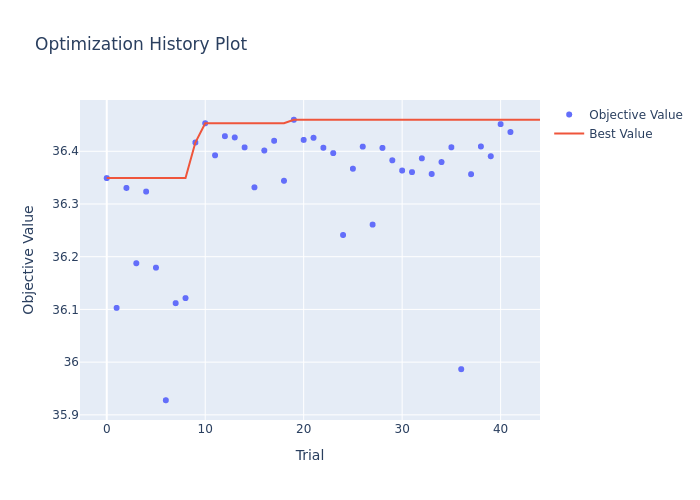

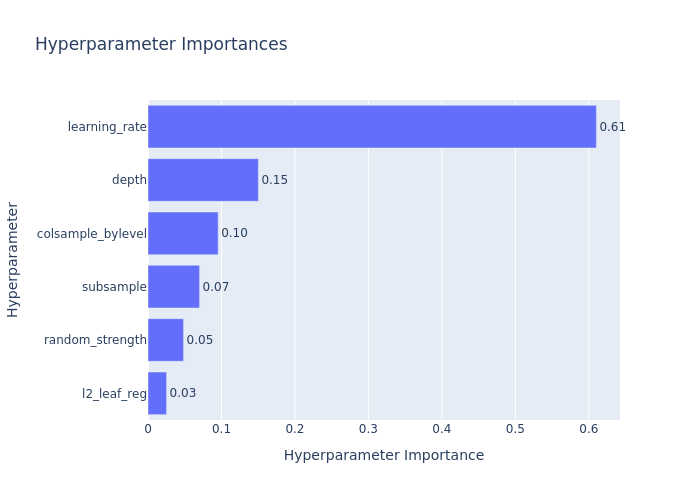

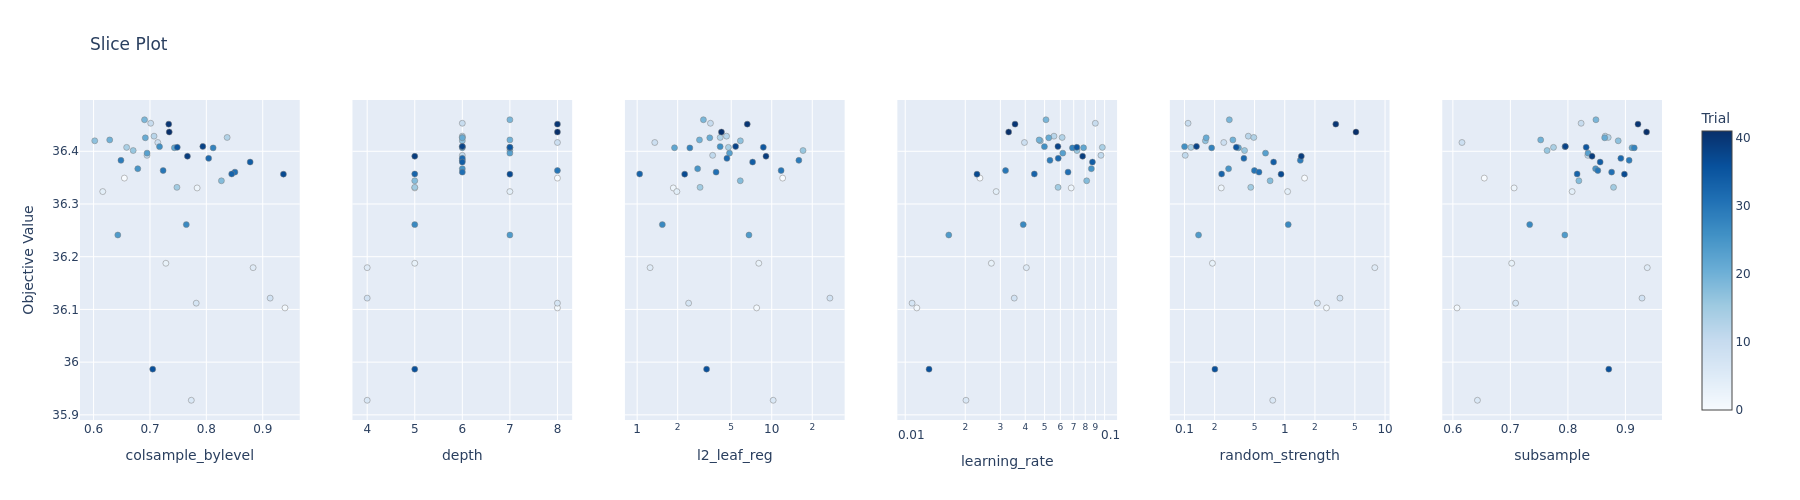

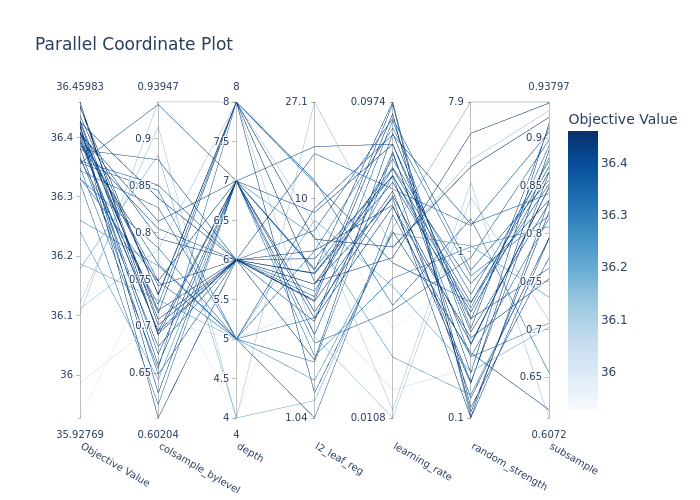

In [8]:
# ==========================================
# ANÁLISE VISUAL DOS TRIALS (OPTUNA)
# ==========================================

optuna.logging.set_verbosity(optuna.logging.WARNING)

db_name = "opt_catboost_credit_v1.db" 
study_name = "estudo_catboost_v1"
study = optuna.create_study(
    study_name=study_name,
    storage=f"sqlite:///{db_name}",
    load_if_exists=True,
    direction='maximize'
)

print("Gerando gráficos..")

# 1. Histórico de Otimização
fig_history = vis.plot_optimization_history(study)
fig_history.write_image(FIGURES_DIR / 'optuna' / '01_historico_otimizacai_v1.png', scale=2)
fig_history.show(renderer='png')

# 2. Importância dos Hiperparâmetros
fig_importances = vis.plot_param_importances(study)
fig_importances.write_image(FIGURES_DIR / 'optuna' / '02_importanica_hiperparametros_v1.png', scale=2)
fig_importances.show(renderer='png')

# 3. Gráfico de Fatias
fig_slice = vis.plot_slice(study)
fig_slice.write_image(FIGURES_DIR / 'optuna' / '03_slice_plot_v1.png', scale=2)
fig_slice.show(renderer='png')

# 4. Gráfico de Coordenadas Paralelas
fig_parallel = vis.plot_parallel_coordinate(study)
fig_parallel.write_image(FIGURES_DIR / 'optuna' / '04_coordenadas_paralelas_v1.png', scale=2)
fig_parallel.show(renderer='png')

In [9]:
# ---------------------------------------------------------
# TREINAMENTO INCREMENTAL (WATERFALL KS) 
# ---------------------------------------------------------
features_acumuladas = []
resultados_incrementais = []
prev_ks_oot = 0.0

print("=" * 105)
print(f"{'BLOCO ADICIONADO':<20} | {'FEATURES':<10} | {'KS TRAIN':<10} | {'KS TEST':<10} | {'KS OOT':<10} | {'Δ KS OOT':<10}")
print("=" * 105)

total_blocos = len(blocos_features)

for i, (nome_bloco, features_do_bloco) in enumerate(blocos_features.items()):
    features_acumuladas.extend(features_do_bloco)
    
    X_tr = df_train[features_acumuladas]
    X_te = df_test[features_acumuladas]
    X_oo = df_oot[features_acumuladas]
    
    clf = CatBoostClassifier(**best_params_final_cat)
    
    clf.fit(
        X_tr, y_train,
        eval_set=(X_te, y_test),
        early_stopping_rounds=150,
        verbose=False
    )
    
    prob_train = clf.predict_proba(X_tr)[:, 1]
    prob_test  = clf.predict_proba(X_te)[:, 1]
    prob_oot   = clf.predict_proba(X_oo)[:, 1]
    
    ks_tr = calc_ks(y_train, prob_train)
    ks_te = calc_ks(y_test, prob_test)
    ks_oo = calc_ks(y_oot, prob_oot)
    
    delta_ks = ks_oo - prev_ks_oot
    etapa_nome = nome_bloco.replace('_', ' ').split(' ', 1)[1]
    gini_oot = calc_gini(y_oot, prob_oot)
    best_iter = clf.best_iteration_
    
    caminho_temp = ARTIFACTS_DIR / f'temp_model_step_{i}.cbm'
    clf.save_model(str(caminho_temp))

    resultados_incrementais.append({
        'Etapa': etapa_nome,
        'Step_Index': i,
        'N_Features': len(features_acumuladas),
        'Features_List': features_acumuladas.copy(),
        'KS_Train': ks_tr,
        'KS_Test': ks_te,
        'KS_OOT': ks_oo,
        'Gini_OOT': gini_oot,
        'Delta_KS': delta_ks,
        'Best_Iteration': best_iter
    })
    
    flag_bench = "🚀 BATEU BENCHMARK!" if ks_oo >= 33.1 else ""
    print(f"{etapa_nome:<20} | {len(features_acumuladas):<10} | {ks_tr:>8.2f}%  | {ks_te:>8.2f}%  | {ks_oo:>8.2f}%  | {delta_ks:>+8.2f}pp {flag_bench}")
    
    prev_ks_oot = ks_oo
    
    del X_tr, X_te, X_oo
    del prob_train, prob_test, prob_oot
    
    if i < total_blocos - 1:
        del clf
        
    gc.collect() 


print("=" * 105)

df_inc_results = pd.DataFrame(resultados_incrementais)

# =========================================================
# SELEÇÃO DA MELHOR ETAPA E RESGATE DO MODELO
# =========================================================
df_inc_results = pd.DataFrame(resultados_incrementais)
melhor_linha = df_inc_results.loc[df_inc_results['KS_OOT'].idxmax()]

best_iteration_global = int(melhor_linha['Best_Iteration'])
melhor_etapa = melhor_linha['Etapa']
melhor_ks = melhor_linha['KS_OOT']
melhor_gini = melhor_linha['Gini_OOT']
best_step_index = int(melhor_linha['Step_Index'])

print("-" * 50)
print(f"✅ KS OOT (Referência):   {melhor_ks:.2f}%")
print(f"✅ Gini OOT (Referência): {melhor_gini:.2f}%")
print(f"✅ Best Iteration:        {best_iteration_global}")
print("-" * 50)

df_inc_results.to_csv(ARTIFACTS_DIR / 'ks_incremental_catboost_v1.csv', index=False)

# ---------------------------------------------------------
# LIMPEZA DE CACHE 
# ---------------------------------------------------------
print("🧹 Limpando modelos temporários do disco...")

import os

for j in range(total_blocos):
    if j != best_step_index:  
        caminho_lixo = ARTIFACTS_DIR / f'temp_model_step_{j}.cbm'
        if caminho_lixo.exists():
            os.remove(caminho_lixo)

print("✨ Limpeza concluída! Apenas o modelo campeão foi mantido no disco.")

BLOCO ADICIONADO     | FEATURES   | KS TRAIN   | KS TEST    | KS OOT     | Δ KS OOT  
Score 1              | 1          |    27.29%  |    27.05%  |    26.14%  |   +26.14pp 
Score 2              | 2          |    32.84%  |    32.73%  |    30.72%  |    +4.58pp 
Telco                | 11         |    33.31%  |    32.90%  |    30.94%  |    +0.22pp 
Cadastro             | 16         |    33.84%  |    33.18%  |    31.21%  |    +0.27pp 
Recarga              | 41         |    38.12%  |    36.12%  |    34.01%  |    +2.80pp 🚀 BATEU BENCHMARK!
Pagamento e Atraso   | 62         |    39.19%  |    36.44%  |    34.53%  |    +0.52pp 🚀 BATEU BENCHMARK!
--------------------------------------------------
✅ KS OOT (Referência):   34.53%
✅ Gini OOT (Referência): 46.60%
✅ Best Iteration:        2071
--------------------------------------------------
🧹 Limpando modelos temporários do disco...
✨ Limpeza concluída! Apenas o modelo campeão foi mantido no disco.


In [10]:
# ---------------------------------------------------------
# INFERÊNCIA E AVALIAÇÃO NO GRUPO CONTROLE (HOLDOUT)
# ---------------------------------------------------------
print("🎯 Carregando o modelo campeão do disco (Zero Retreino) e aplicando no Controle...")

# 1. Resgatando as features exatas da melhor etapa
features_campeas = melhor_linha['Features_List']

# 2. Carregando Modelo
caminho_campeao = ARTIFACTS_DIR / f'temp_model_step_{best_step_index}.cbm'
modelo_final = CatBoostClassifier()
modelo_final.load_model(str(caminho_campeao))

# 3. Grupo Controle com as mesmas features
X_controle = df_controle[features_campeas]
y_controle = df_controle['target']

# 4. Inferência e Métricas
prob_controle = modelo_final.predict_proba(X_controle)[:, 1]
ks_controle = calc_ks(y_controle, prob_controle)
gini_controle = calc_gini(y_controle, prob_controle)

print("-" * 50)
print(f"✅ KS Grupo Controle:   {ks_controle:.2f}%")
print(f"✅ Gini Grupo Controle: {gini_controle:.2f}%")
print("-" * 50)

🎯 Carregando o modelo campeão do disco (Zero Retreino) e aplicando no Controle...
--------------------------------------------------
✅ KS Grupo Controle:   42.67%
✅ Gini Grupo Controle: 56.25%
--------------------------------------------------


In [11]:
# =========================================================
# ANÁLISE DE SWAP-IN / SWAP-OUT (BUSINESS VALUE)
# =========================================================
CUTOFF_PCT = 70.0 

df_swap = df_controle[['num_cpf', 'target', 'bur_score_02']].copy()
df_swap['prob_modelo'] = prob_controle

# Definição de Cutoffs (Top 70% Bureau vs Bottom 70% Risco Modelo)
cutoff_bureau = np.nanpercentile(df_swap['bur_score_02'], 100 - CUTOFF_PCT)
cutoff_modelo = np.percentile(df_swap['prob_modelo'], CUTOFF_PCT)

df_swap['aprova_bureau'] = (df_swap['bur_score_02'] >= cutoff_bureau).fillna(False).astype(int)
df_swap['aprova_modelo'] = (df_swap['prob_modelo'] <= cutoff_modelo).astype(int)

# Regras de Negócio (Matriz de Decisão)
conditions = [
    (df_swap['aprova_modelo'] == 1) & (df_swap['aprova_bureau'] == 1),
    (df_swap['aprova_modelo'] == 0) & (df_swap['aprova_bureau'] == 0),
    (df_swap['aprova_modelo'] == 1) & (df_swap['aprova_bureau'] == 0),
    (df_swap['aprova_modelo'] == 0) & (df_swap['aprova_bureau'] == 1),
]
choices = ['1. Ambos Aprovam', '4. Ambos Rejeitam', '2. Swap-In (Oportunidade)', '3. Swap-Out (Proteção)']
df_swap['categoria'] = np.select(conditions, choices, default='Indefinido')

# Agregação Analítica
swap_summary = df_swap.groupby('categoria').agg(
    Volume=('target', 'count'),
    Bads=('target', 'sum'),
    Bad_Rate=('target', 'mean'),
    Prob_Media_Modelo=('prob_modelo', 'mean')
).reset_index().sort_values('categoria')

swap_summary['% Base'] = swap_summary['Volume'] / swap_summary['Volume'].sum()

print("=" * 100)
print(f"MATRIZ DE SWAP-IN / SWAP-OUT - GRUPO CONTROLE (Aprovação Alvo: {CUTOFF_PCT}%)")
print("=" * 100)
display(swap_summary[['categoria', 'Volume', '% Base', 'Bads', 'Bad_Rate', 'Prob_Media_Modelo']].style.format({
    'Volume': '{:,.0f}', 'Bads': '{:,.0f}', 
    '% Base': '{:.1%}', 'Bad_Rate': '{:.2%}', 'Prob_Media_Modelo': '{:.4f}'
}).background_gradient(subset=['Bad_Rate'], cmap='RdYlGn_r'))

# Interpretação de Impacto na Carteira
try:
    br_in = float(swap_summary.loc[swap_summary['categoria'].str.contains('Swap-In'), 'Bad_Rate'].iloc[0])
    br_out = float(swap_summary.loc[swap_summary['categoria'].str.contains('Swap-Out'), 'Bad_Rate'].iloc[0])
    vol_in = int(swap_summary.loc[swap_summary['categoria'].str.contains('Swap-In'), 'Volume'].iloc[0])

    print("\n💡 AVALIAÇÃO DE IMPACTO NO NEGÓCIO:")
    print("-" * 60)
    print(f"• Swap-In (Reprovados Bureau -> Aprovados Modelo): Bad Rate = {br_in:.2%}")
    print(f"• Swap-Out (Aprovados Bureau -> Barrados Modelo): Bad Rate = {br_out:.2%}")
    
    if br_in < br_out:
        print(f"\n✅ VALIDAÇÃO BEM-SUCEDIDA: O modelo otimiza o risco da carteira.")
        print(f"   Redução de risco no volume rotacionado: {br_out - br_in:.2%} pp.")
    else:
        print(f"\n⚠️ ATENÇÃO: Risco de Swap-In excede Swap-Out. Revisar calibração de Cutoff.")
except IndexError:
    print("\n⚠️ Não foi possível calcular o delta de Swap (Categorias ausentes).")

# Matriz de Confusão 
y_pred_modelo = (df_swap['prob_modelo'] > cutoff_modelo).astype(int)
print("\n📊 MATRIZ DE CONFUSÃO (Real vs. Predito Modelo):")
print(pd.crosstab(df_swap['target'], y_pred_modelo, rownames=['Real (0=Good, 1=Bad)'], colnames=['Predito (0=Aprova, 1=Rejeita)']))

# ---------------------------------------------------------
# EXPORTAÇÃO DA BASE ESCORADA PARA O NOTEBOOK DE NEGÓCIOS
# ---------------------------------------------------------
nome_arquivo = 'base_escorada_swap_v1.parquet' 
caminho_salvamento = ARTIFACTS_DIR / nome_arquivo
df_swap.to_parquet(caminho_salvamento, index=False)
print(f"\n💾 Base para simulação de negócios salva com sucesso em: {caminho_salvamento}")

MATRIZ DE SWAP-IN / SWAP-OUT - GRUPO CONTROLE (Aprovação Alvo: 70.0%)


,categoria,Volume,% Base,Bads,Bad_Rate,Prob_Media_Modelo
0,1. Ambos Aprovam,"70,350",63.8%,"12,245",17.41%,0.1631
1,2. Swap-In (Oportunidade),"6,837",6.2%,"2,248",32.88%,0.3052
2,3. Swap-Out (Proteção),"7,066",6.4%,"3,683",52.12%,0.4876
3,4. Ambos Rejeitam,"26,015",23.6%,"15,737",60.49%,0.5719



💡 AVALIAÇÃO DE IMPACTO NO NEGÓCIO:
------------------------------------------------------------
• Swap-In (Reprovados Bureau -> Aprovados Modelo): Bad Rate = 32.88%
• Swap-Out (Aprovados Bureau -> Barrados Modelo): Bad Rate = 52.12%

✅ VALIDAÇÃO BEM-SUCEDIDA: O modelo otimiza o risco da carteira.
   Redução de risco no volume rotacionado: 19.24% pp.

📊 MATRIZ DE CONFUSÃO (Real vs. Predito Modelo):
Predito (0=Aprova, 1=Rejeita)      0      1
Real (0=Good, 1=Bad)                       
0                              62694  13661
1                              14493  19420

💾 Base para simulação de negócios salva com sucesso em: ../../reports/observability/modeling/v1/artifacts/base_escorada_swap_v1.parquet


In [12]:
# =========================================================
# CÁLCULO DE PSI E SERIALIZAÇÃO DO ARTEFATO (DEPLOY)
# =========================================================
print("📊 Calculando métricas de estabilidade (PSI) e compilando artefato...")

def calc_psi(expected, actual, bins=10):
    bins_cuts = np.percentile(expected, np.linspace(0, 100, bins + 1))
    bins_cuts[0], bins_cuts[-1] = -np.inf, np.inf
    
    expected_pct = np.histogram(expected, bins=bins_cuts)[0] / len(expected)
    actual_pct = np.histogram(actual, bins=bins_cuts)[0] / len(actual)
    
    expected_pct = np.where(expected_pct == 0, 0.0001, expected_pct)
    actual_pct = np.where(actual_pct == 0, 0.0001, actual_pct)
    
    return np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))

X_tr_campeao = df_train[features_campeas]
prob_train = modelo_final.predict_proba(X_tr_campeao)[:, 1]

X_oot = df_oot[features_campeas]
y_oot = df_oot['target']
prob_oot_final = modelo_final.predict_proba(X_oot)[:, 1]

psi_oot_real = calc_psi(prob_train, prob_oot_final)
print(f"⚖️  PSI Calculado (Treino vs OOT): {psi_oot_real:.4f}")

gini_oot = calc_gini(y_oot, prob_oot_final)
deltas = {res['Etapa']: res['Delta_KS'] for res in resultados_incrementais}

waterfall_dict = {
    'Bureau': round(deltas.get('Score 1', 0.0) + deltas.get('Score 2', 0.0), 2),
    '+ Telco': round(deltas.get('Telco', 0.0), 2),
    '+ Cadastral': round(deltas.get('Cadastro', 0.0), 2),
    '+ Recarga': round(deltas.get('Recarga', 0.0), 2),
    '+ Pagamento': round(deltas.get('Pagamento', 0.0), 2),
    '+ Atraso': round(deltas.get('Atraso', 0.0), 2) 
}

model_artifact = {
    'model': modelo_final,
    'woe_encoder': None,
    'features_raw': todas_features,
    'metadata': {
        'version': 'catboost_v1.0',
        'algorithm': 'CatBoost',
        'created_at': datetime.now().isoformat(),
        'gini_oot': float(gini_oot),
        'ks_oot': float(melhor_ks),
        'psi_oot': float(psi_oot_real),
        'ks_bench': 33.1,            
        'cutoff_modelo_pct': float(CUTOFF_PCT),            
        'cutoff_bureau_pct': 100.0 - float(CUTOFF_PCT),            
        'waterfall_steps': waterfall_dict
    }
}

pkl_path = MODELS_DIR / 'behavior_catboost_v1.pkl' 
with open(pkl_path, 'wb') as f:
    pickle.dump(model_artifact, f)

print(f"✅ Artefato serializado com sucesso em: {pkl_path}")

📊 Calculando métricas de estabilidade (PSI) e compilando artefato...
⚖️  PSI Calculado (Treino vs OOT): 0.0010
✅ Artefato serializado com sucesso em: ../../reports/observability/modeling/v1/models/behavior_catboost_v1.pkl


📊 Gerando artefatos visuais para a apresentação...


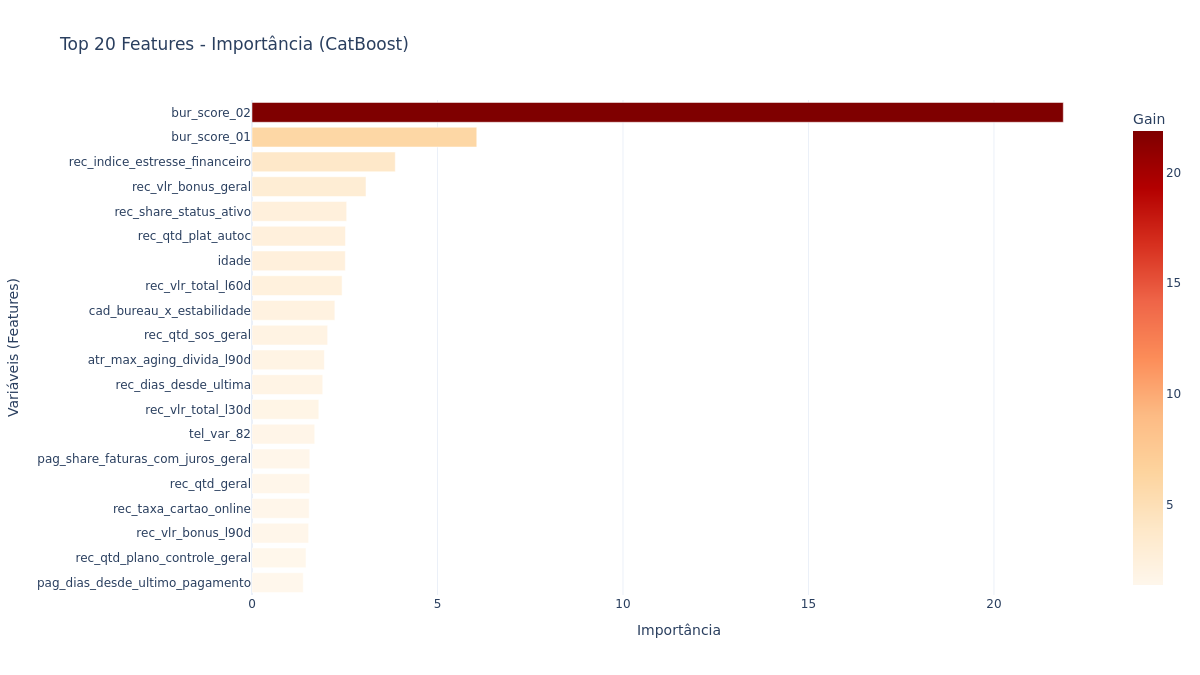

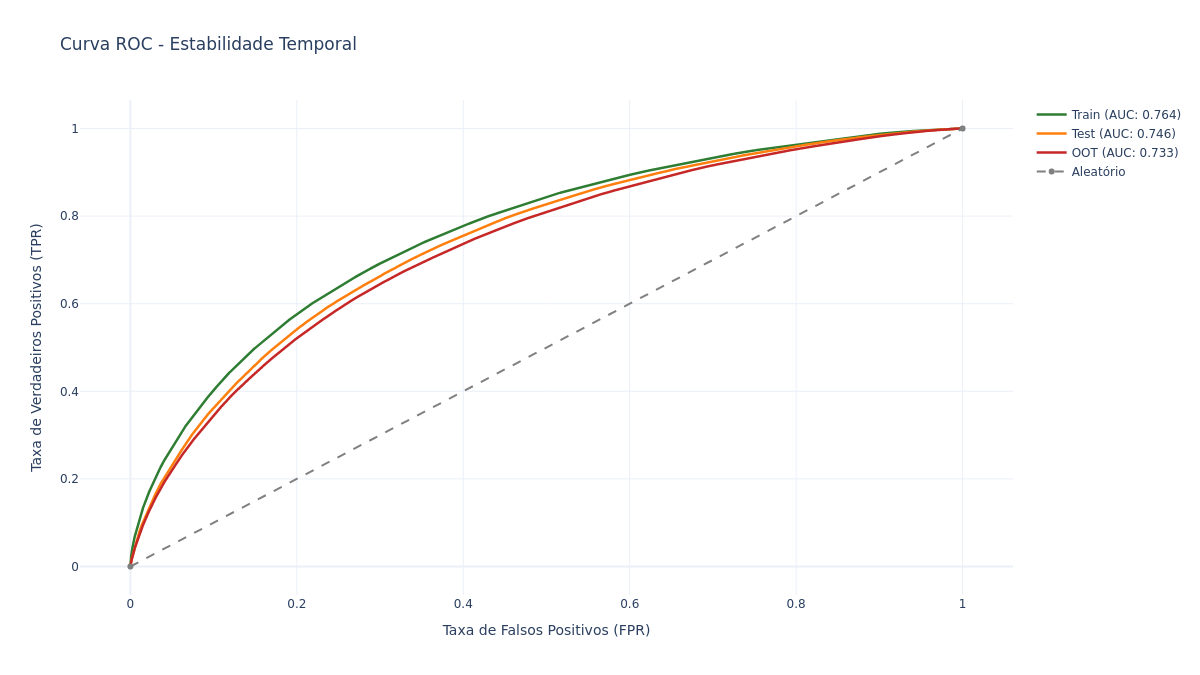

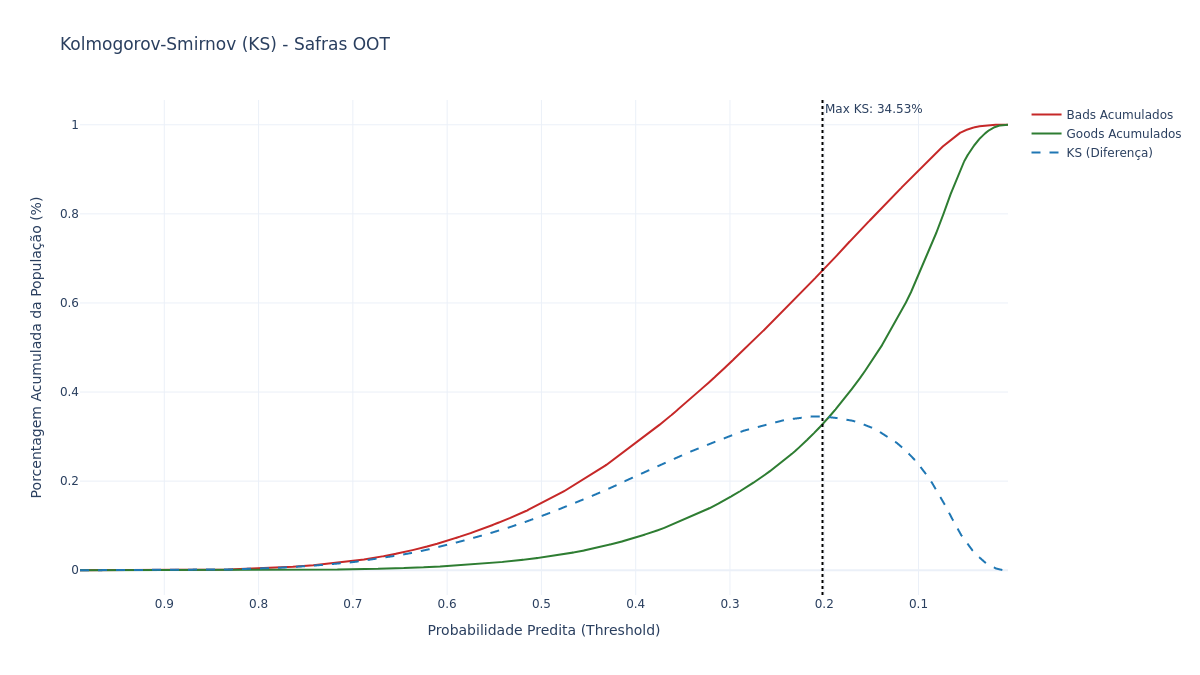

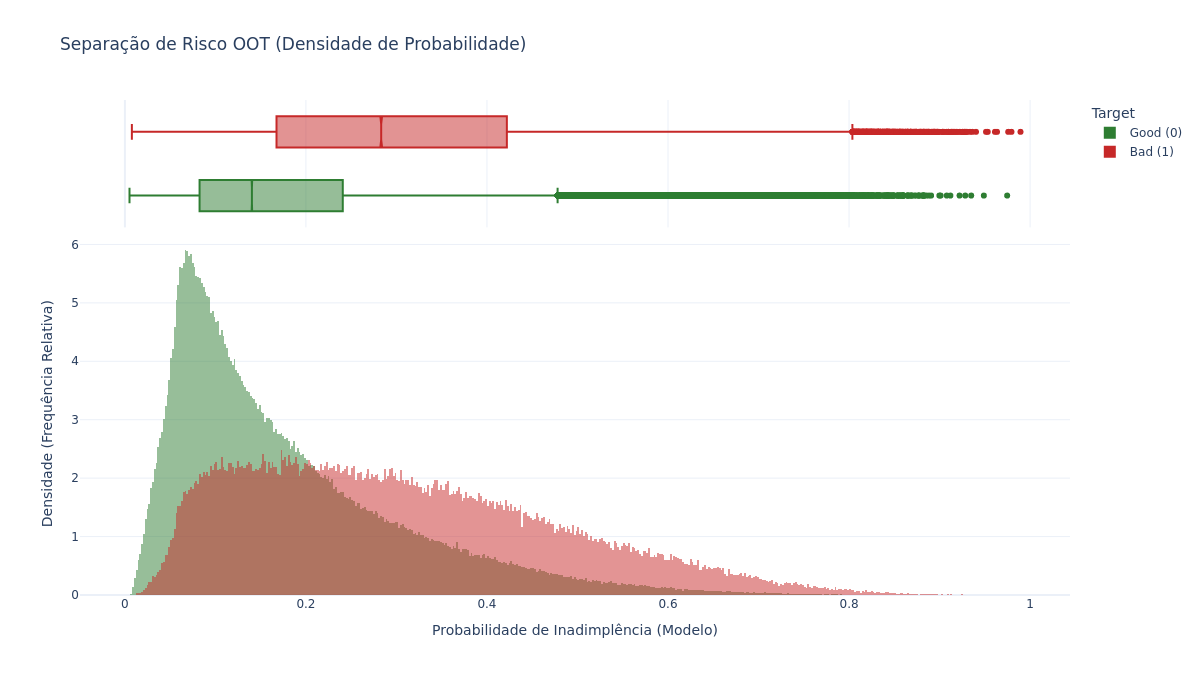

In [13]:
# ---------------------------------------------------------
# 1. FEATURE IMPORTANCE
# ---------------------------------------------------------
print("📊 Gerando artefatos visuais para a apresentação...")

X_te = df_test[features_campeas]
prob_test  = modelo_final.predict_proba(X_te)[:, 1]

# 1. Feature Importance (CatBoost Native)
importances = modelo_final.get_feature_importance()
df_imp = pd.DataFrame({'Feature': features_campeas, 'Gain': importances}).sort_values('Gain', ascending=True).tail(20)

fig_imp = px.bar(df_imp, x='Gain', y='Feature', orientation='h', title='Top 20 Features - Importância (CatBoost)',
                 color='Gain', color_continuous_scale='OrRd')
fig_imp.update_layout(template='plotly_white', height=675, width=1200, xaxis_title='Importância', yaxis_title='Variáveis (Features)')
fig_imp.write_image(FIGURES_DIR / '01_importancia_das_features_v1.png', scale=2)
fig_imp.show(renderer='png')

# ---------------------------------------------------------
# 2. CURVAS ROC COMPARATIVAS
# ---------------------------------------------------------
fig_roc = go.Figure()
for name, y_true, y_prob, color in [('Train', y_train, prob_train, COLORS['good']), 
                                    ('Test', y_test, prob_test, '#ff7f0e'), 
                                    ('OOT', y_oot, prob_oot_final, COLORS['bad'])]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'{name} (AUC: {auc(fpr, tpr):.3f})', line=dict(color=color, width=2.5)))

fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], line=dict(dash='dash', color='gray'), name='Aleatório'))
fig_roc.update_layout(title='Curva ROC - Estabilidade Temporal', xaxis_title='Taxa de Falsos Positivos (FPR)', yaxis_title='Taxa de Verdadeiros Positivos (TPR)', template='plotly_white', height=675, width=1200)
fig_roc.write_image(FIGURES_DIR / '02_curva_roc_v1.png', scale=2)
fig_roc.show(renderer='png')

# ---------------------------------------------------------
# 3. KS CURVE (OOT)
# ---------------------------------------------------------
fpr_oot, tpr_oot, thresholds_oot = roc_curve(y_oot, prob_oot_final)
ks_curve = tpr_oot - fpr_oot
ks_idx = np.argmax(ks_curve)

fig_ks = go.Figure()
fig_ks.add_trace(go.Scatter(x=thresholds_oot, y=tpr_oot, name='Bads Acumulados', line=dict(color=COLORS['bad'])))
fig_ks.add_trace(go.Scatter(x=thresholds_oot, y=fpr_oot, name='Goods Acumulados', line=dict(color=COLORS['good'])))
fig_ks.add_trace(go.Scatter(x=thresholds_oot, y=ks_curve, name='KS (Diferença)', line=dict(color='#1f77b4', dash='dash')))
fig_ks.add_vline(x=thresholds_oot[ks_idx], line_dash="dot", line_color="black", annotation_text=f"Max KS: {ks_curve[ks_idx]:.2%}")
fig_ks.update_layout(title='Kolmogorov-Smirnov (KS) - Safras OOT', xaxis_title='Probabilidade Predita (Threshold)', yaxis_title='Porcentagem Acumulada da População (%)', xaxis=dict(autorange="reversed"), template='plotly_white', height=675, width=1200)
fig_ks.write_image(FIGURES_DIR / '03_curva_ks_v1.png', scale=2)
fig_ks.show(renderer='png')

# ---------------------------------------------------------
# 4. DISTRIBUIÇÃO DE PROBABILIDADE POR TARGET
# ---------------------------------------------------------
df_dist = pd.DataFrame({'Probabilidade': prob_oot_final, 'Target': y_oot.map({0: 'Good (0)', 1: 'Bad (1)'})})
fig_dist = px.histogram(df_dist, x='Probabilidade', color='Target', marginal='box', barmode='overlay', histnorm='probability density',
                        color_discrete_map={'Good (0)': COLORS['good'], 'Bad (1)': COLORS['bad']}, title='Separação de Risco OOT (Densidade de Probabilidade)')
fig_dist.update_layout(template='plotly_white', height=675, width=1200, xaxis_title='Probabilidade de Inadimplência (Modelo)', yaxis_title='Densidade (Frequência Relativa)')
fig_dist.write_image(FIGURES_DIR / '04_distribuicao_probabilidade_v1.png', scale=2)
fig_dist.show(renderer='png')

📊 Gerando Análise de Decis (Gains Table)...


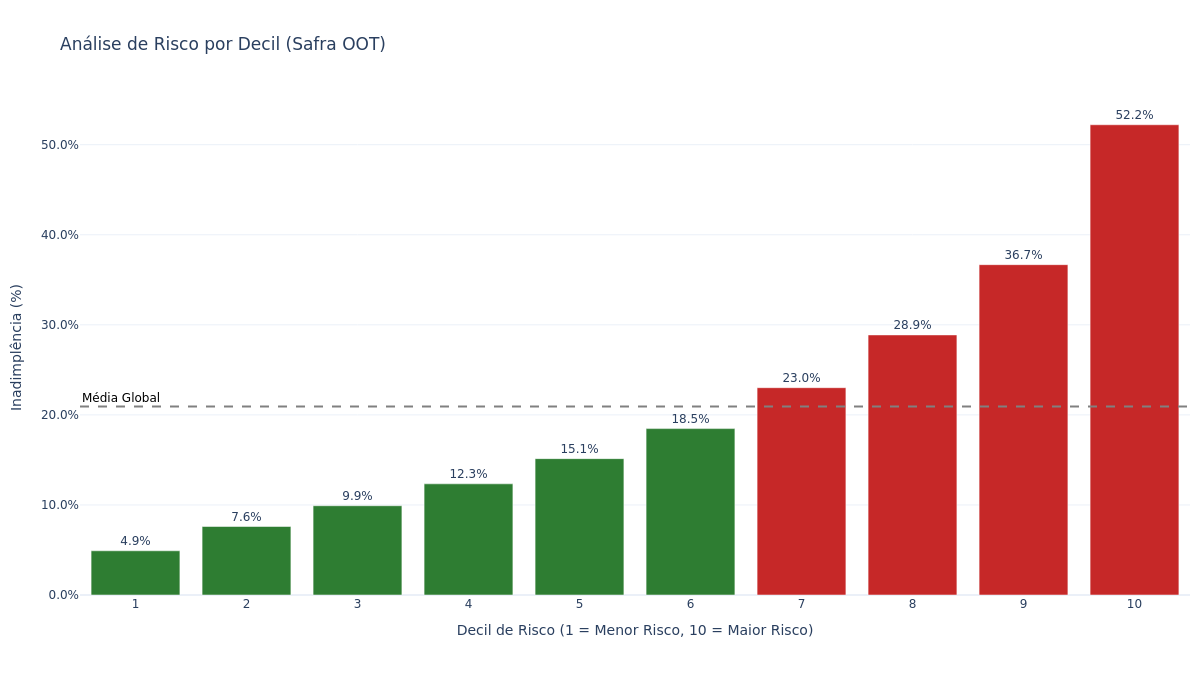

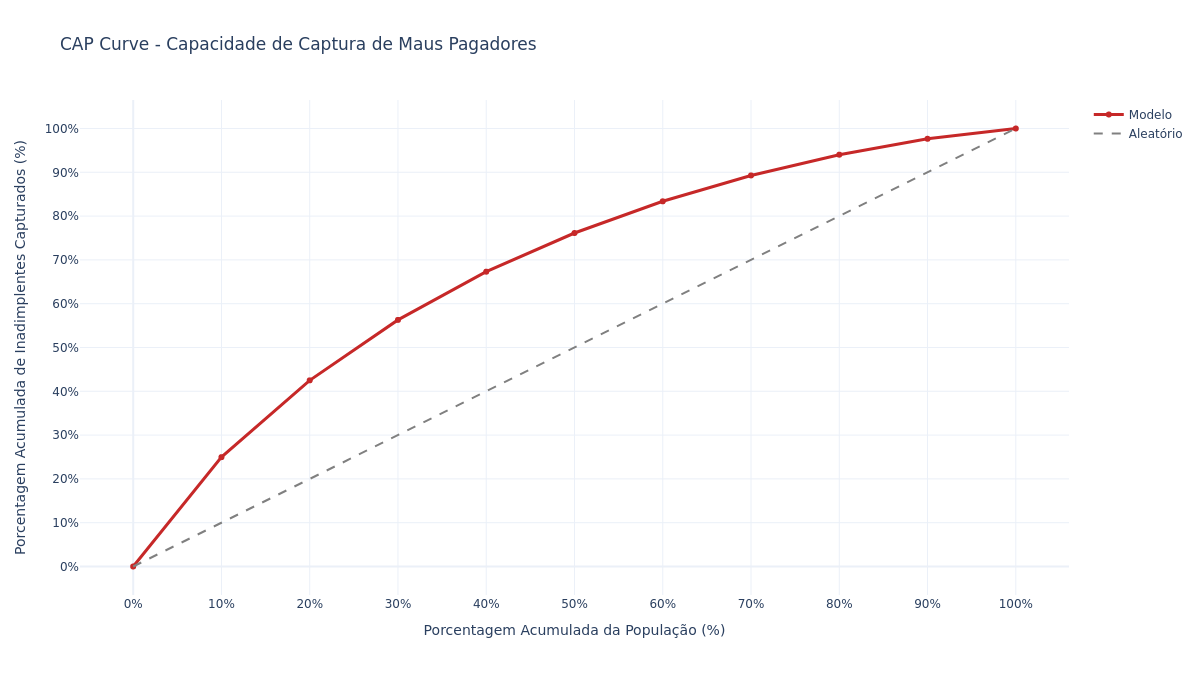

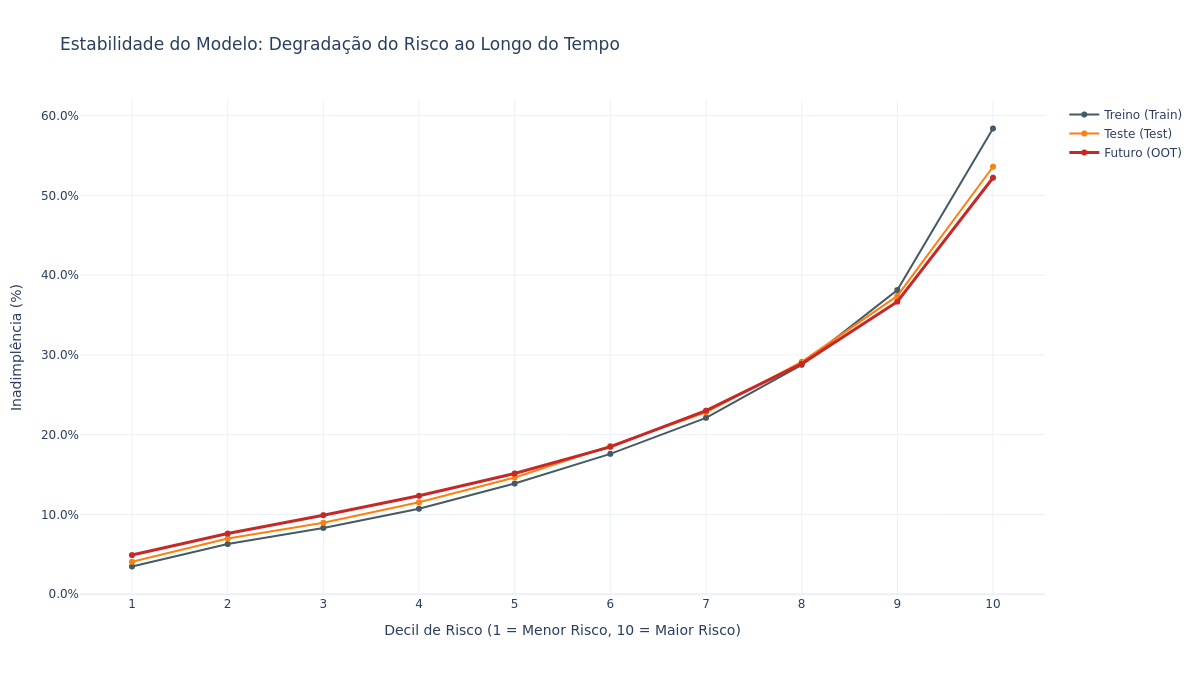

In [14]:
# ---------------------------------------------------------
# 5. BAD RATE POR DECIL
# ---------------------------------------------------------
print("📊 Gerando Análise de Decis (Gains Table)...")

def create_gains_table(y_true, y_prob, n_bins=10, label=''):
    tmp = pd.DataFrame({'y': y_true, 'prob': y_prob})
    tmp['decil'] = pd.qcut(tmp['prob'], q=n_bins, labels=False, duplicates='drop') + 1
    gt = tmp.groupby('decil').agg(n=('y', 'count'), n_bad=('y', 'sum')).reset_index()
    gt['bad_rate'] = gt['n_bad'] / gt['n']
    
    gt_sorted = gt.sort_values('decil', ascending=False).copy()
    gt_sorted['cum_pct_bad_desc'] = gt_sorted['n_bad'].cumsum() / gt_sorted['n_bad'].sum()
    gt_sorted['cum_pct_pop_desc'] = gt_sorted['n'].cumsum() / gt_sorted['n'].sum()
    return gt, gt_sorted

gt_train, _ = create_gains_table(y_train, prob_train)
gt_test, _  = create_gains_table(y_test, prob_test)
gt_oot, gt_oot_desc = create_gains_table(y_oot, prob_oot_final) 

media_global_oot = y_oot.mean()

fig_decis = go.Figure()
colors_decil = [COLORS['bad'] if br > media_global_oot else COLORS['good'] for br in gt_oot['bad_rate']]
fig_decis.add_trace(go.Bar(x=gt_oot['decil'], y=gt_oot['bad_rate'], marker_color=colors_decil, name='Bad Rate OOT', texttemplate='%{y:.1%}', textposition='outside'))
fig_decis.add_hline(y=media_global_oot, line_dash='dash', line_color='gray', annotation_text='Média Global', annotation_font_color='#000', annotation_position='top left')
fig_decis.update_layout(template='plotly_white', height=675, width=1200, title_text='Análise de Risco por Decil (Safra OOT)', xaxis_title="Decil de Risco (1 = Menor Risco, 10 = Maior Risco)", yaxis_title="Inadimplência (%)", margin=dict(r=10))
fig_decis.update_xaxes(tickmode='linear', dtick=1)
fig_decis.update_yaxes(tickformat='.1%')
fig_decis.write_image(FIGURES_DIR / '05_ganhos_por_decis_v1.png', scale=2)
fig_decis.show(renderer='png')

# ---------------------------------------------------------
# 6. CAP CURVE
# ---------------------------------------------------------
fig_cap = go.Figure()
cum_pop = np.concatenate([[0], gt_oot_desc['cum_pct_pop_desc'].values])
cum_bad = np.concatenate([[0], gt_oot_desc['cum_pct_bad_desc'].values])
fig_cap.add_trace(go.Scatter(x=cum_pop, y=cum_bad, mode='lines+markers', name='Modelo', line=dict(color=COLORS['bad'], width=3)))
fig_cap.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash', color='gray'), name='Aleatório'))
fig_cap.update_layout(template='plotly_white', height=675, width=1200, title_text='CAP Curve - Capacidade de Captura de Maus Pagadores', xaxis_title="Porcentagem Acumulada da População (%)", yaxis_title="Porcentagem Acumulada de Inadimplentes Capturados (%)")
fig_cap.update_xaxes(tickmode='linear', dtick=0.1, tickformat='.0%')
fig_cap.update_yaxes(tickmode='linear', dtick=0.1, tickformat='.0%')
fig_cap.write_image(FIGURES_DIR / '06_curva_de_ganhos_cap_v1.png', scale=2)
fig_cap.show(renderer='png')

# ---------------------------------------------------------
# 7. ESTABILIDADE DE DCIS
# ---------------------------------------------------------
fig_estab = go.Figure()
fig_estab.add_trace(go.Scatter(x=gt_train['decil'], y=gt_train['bad_rate'], mode='lines+markers', name='Treino (Train)', line=dict(color=COLORS['neutral'], width=2)))
fig_estab.add_trace(go.Scatter(x=gt_test['decil'], y=gt_test['bad_rate'], mode='lines+markers', name='Teste (Test)', line=dict(color='#ff7f0e', width=2)))
fig_estab.add_trace(go.Scatter(x=gt_oot['decil'], y=gt_oot['bad_rate'], mode='lines+markers', name='Futuro (OOT)', line=dict(color=COLORS['bad'], width=3)))
fig_estab.update_layout(template='plotly_white', height=675, width=1200, title_text='Estabilidade do Modelo: Degradação do Risco ao Longo do Tempo', xaxis_title="Decil de Risco (1 = Menor Risco, 10 = Maior Risco)", yaxis_title="Inadimplência (%)")
fig_estab.update_xaxes(tickmode='linear', dtick=1)
fig_estab.update_yaxes(tickformat='.1%')
fig_estab.write_image(FIGURES_DIR / '07_estabilidade_de_ganhos_v1.png', scale=2)
fig_estab.show(renderer='png')

📊 Gerando Gráfico de Estabilidade (PSI)...


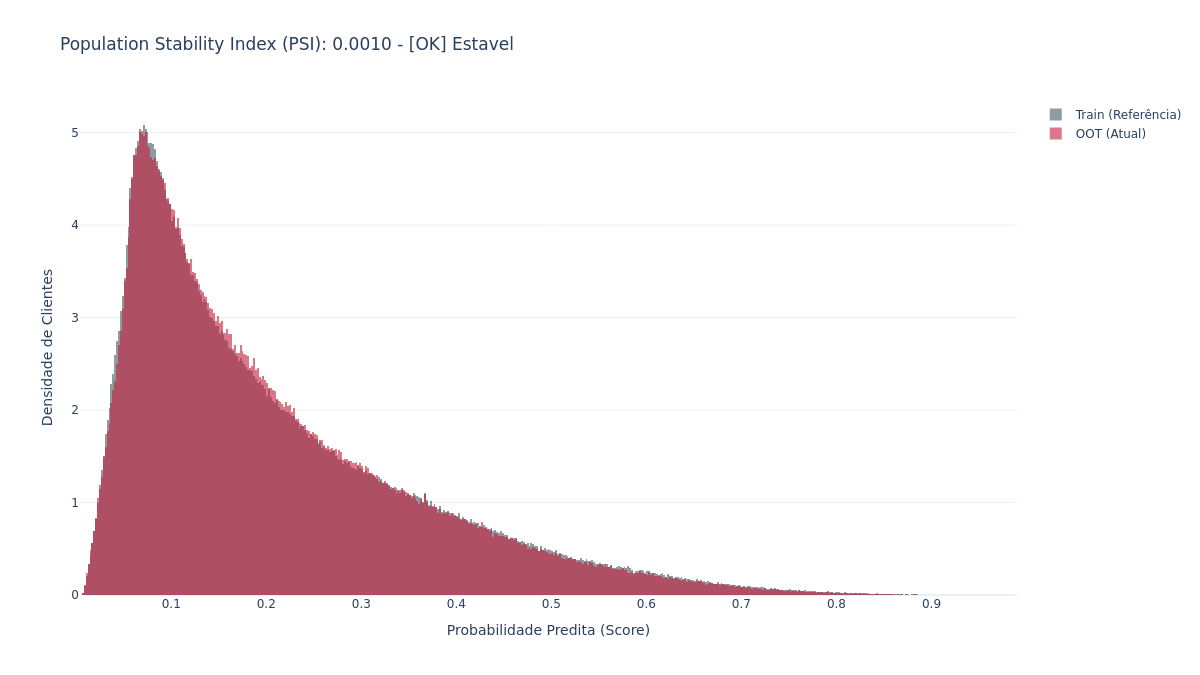

In [15]:
# ---------------------------------------------------------
# 8. ESTABILIDADE DO SCORE (PSI)
# ---------------------------------------------------------
print("📊 Gerando Gráfico de Estabilidade (PSI)...")

def calculate_psi(expected, actual, n_bins=10):
    _, edges = pd.qcut(expected, q=n_bins, retbins=True, duplicates='drop')
    edges[0], edges[-1] = -np.inf, np.inf
    exp_pct = pd.Series(pd.cut(expected, bins=edges)).value_counts(normalize=True, sort=False).clip(lower=0.0001)
    act_pct = pd.Series(pd.cut(actual, bins=edges)).value_counts(normalize=True, sort=False).clip(lower=0.0001)
    return ((act_pct - exp_pct) * np.log(act_pct / exp_pct)).sum()

psi_oot = calculate_psi(prob_train, prob_oot_final)
status_psi = "[OK] Estavel" if psi_oot < 0.1 else "[! ] Monitorar" if psi_oot < 0.25 else "[!!] Investigar"

fig_psi = go.Figure()
fig_psi.add_trace(go.Histogram(x=prob_train, histnorm='probability density', name='Train (Referência)', marker_color=COLORS['neutral'], opacity=0.6))
fig_psi.add_trace(go.Histogram(x=prob_oot_final, histnorm='probability density', name='OOT (Atual)', marker_color=COLORS['accent'], opacity=0.6))
fig_psi.update_layout(barmode='overlay', title=f'Population Stability Index (PSI): {psi_oot:.4f} - {status_psi}', xaxis_title='Probabilidade Predita (Score)', yaxis_title='Densidade de Clientes', template='plotly_white', height=675, width=1200)
fig_psi.write_image(FIGURES_DIR / '08_distribuicao_psi_v1.png', scale=2)
fig_psi.show(renderer='png')

📊 Gerando Gráfico de KS Incremental...


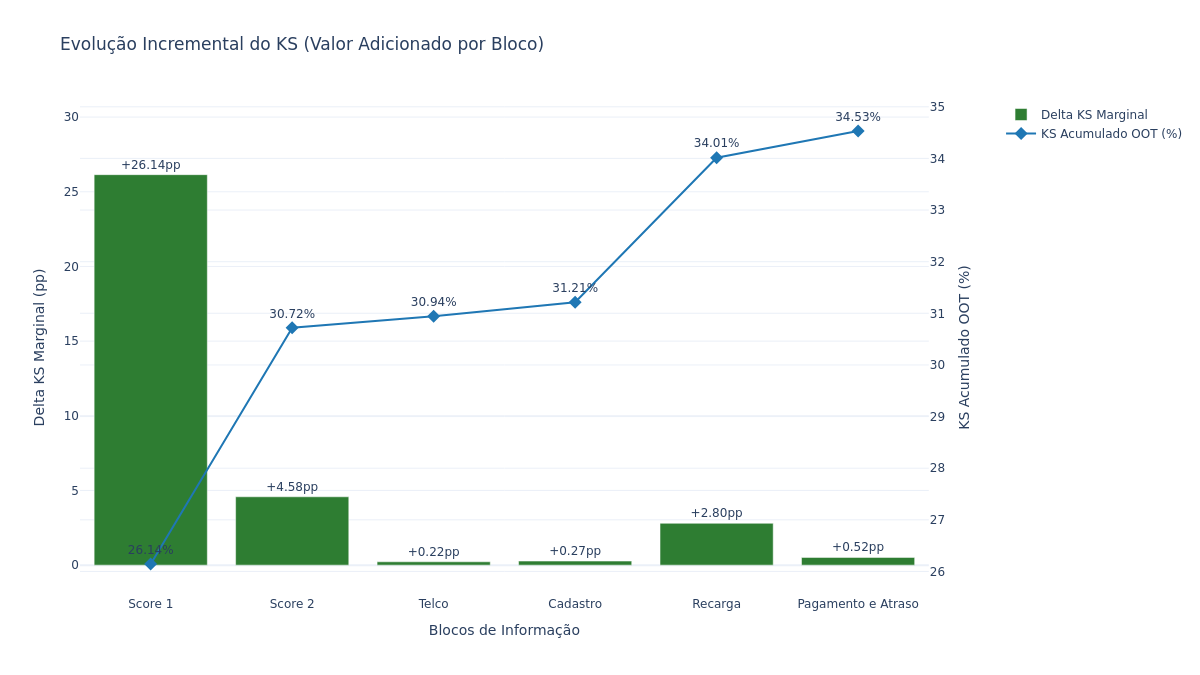

In [16]:
# ---------------------------------------------------------
# 9. KS INCREMENTAL 
# ---------------------------------------------------------
print("📊 Gerando Gráfico de KS Incremental...")

df_inc_results['Etapa_Fmt'] = df_inc_results['Etapa'].str.replace('_', ' ')
fig_inc = make_subplots(specs=[[{"secondary_y": True}]])
colors_inc = [COLORS['good'] if d > 0 else COLORS['bad'] for d in df_inc_results['Delta_KS']]
fig_inc.add_trace(go.Bar(x=df_inc_results['Etapa_Fmt'], y=df_inc_results['Delta_KS'], name='Delta KS Marginal', marker_color=colors_inc, text=df_inc_results['Delta_KS'].apply(lambda x: f'{x:+.2f}pp'), textposition='outside'), secondary_y=False)
fig_inc.add_trace(go.Scatter(x=df_inc_results['Etapa_Fmt'], y=df_inc_results['KS_OOT'], mode='lines+markers+text', name='KS Acumulado OOT (%)', marker=dict(symbol='diamond', size=10, color='#1f77b4'), text=df_inc_results['KS_OOT'].apply(lambda x: f'{x:.2f}%'), textposition='top center'), secondary_y=True)
fig_inc.update_layout(title='Evolução Incremental do KS (Valor Adicionado por Bloco)', template='plotly_white', height=675, width=1200, xaxis_title="Blocos de Informação")
fig_inc.update_yaxes(title_text="Delta KS Marginal (pp)", secondary_y=False, range=[-2, max(df_inc_results['Delta_KS'])+5])
fig_inc.update_yaxes(title_text="KS Acumulado OOT (%)", secondary_y=True)
fig_inc.write_image(FIGURES_DIR / '09_ks_incremental_v1.png', scale=2)
fig_inc.show(renderer='png')

📊 Gerando Composição do KS por Fonte de Dados...


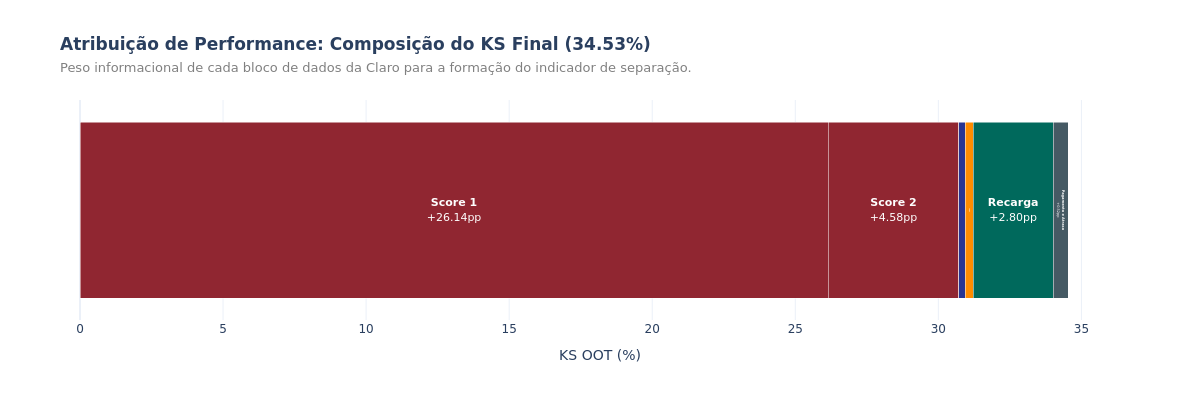

In [17]:
# ---------------------------------------------------------
# 10. COMPOSIÇÃO DO KS INCREMENTAL
# ---------------------------------------------------------
print("📊 Gerando Composição do KS por Fonte de Dados...")

df_inc_plot = df_inc_results[df_inc_results['Delta_KS'] > 0].copy()
fig_comp = go.Figure()
for _, row in df_inc_plot.iterrows():
    cor = COLORS['neutral']
    if 'Score' in row['Etapa']: cor = '#902631'     
    elif 'Telco' in row['Etapa']: cor = '#283593'    
    elif 'Cadastro' in row['Etapa']: cor = '#ff8c00'
    elif 'Recarga' in row['Etapa']: cor = '#00695C' 
    elif 'Pagamento e Atraso' in row['Etapa']: cor = '#455A64'
    fig_comp.add_trace(go.Bar(y=['KS Total (OOT)'], x=[row['Delta_KS']], name=row['Etapa'], orientation='h', marker_color=cor, text=f"<b>{row['Etapa']}</b><br>+{row['Delta_KS']:.2f}pp", textposition='inside', insidetextanchor='middle', textfont=dict(color='white', size=11)))
ks_final = melhor_ks
fig_comp.update_layout(barmode='stack', title=f"<b>Atribuição de Performance: Composição do KS Final ({ks_final:.2f}%)</b><br><span style='font-size:13px;color:gray'>Peso informacional de cada bloco de dados da Claro para a formação do indicador de separação.</span>", height=400, width=1200, template="plotly_white", xaxis_title="KS OOT (%)", showlegend=False, yaxis_visible=False)
fig_comp.write_image(FIGURES_DIR / '10_composicao_ks_v1.png', scale=2)
fig_comp.show(renderer='png')

📊 Gerando Análise de Data Drift (PSI por Variável)...


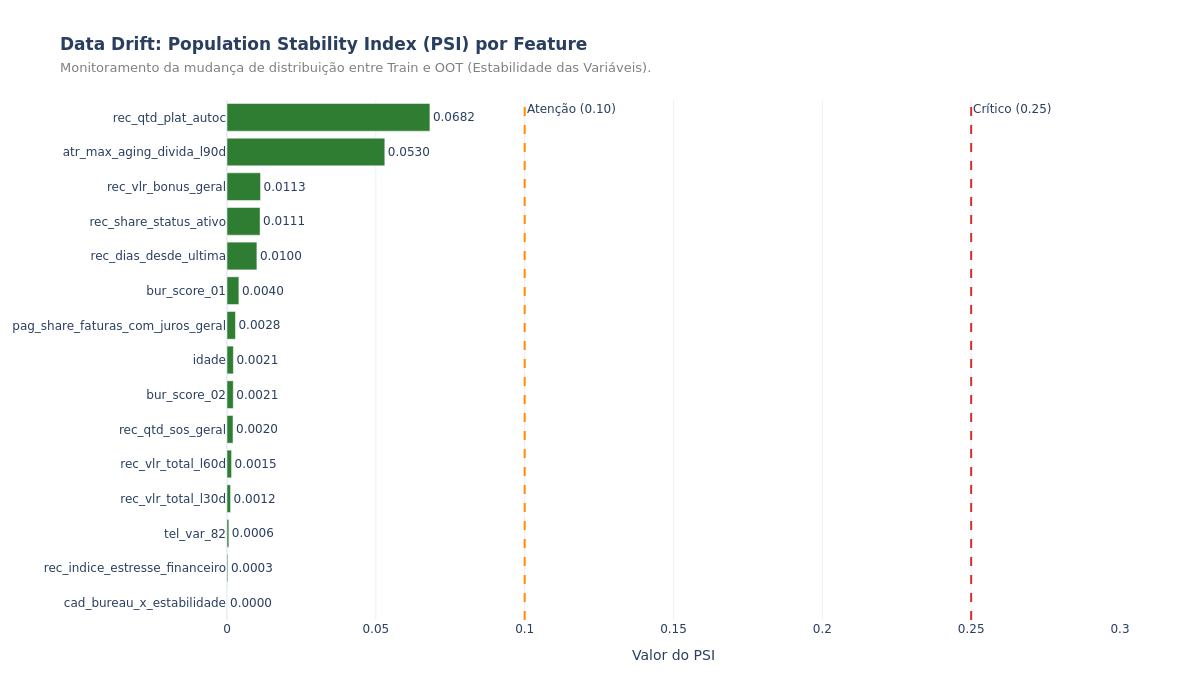

In [18]:
# ---------------------------------------------------------
# 11. DATA DRIFT: POPULATION STABILITY INDEX POR FEATURE
# ---------------------------------------------------------
print("📊 Gerando Análise de Data Drift (PSI por Variável)...")

def calculate_feature_psi(expected, actual, n_bins=10):
    expected_clean = pd.Series(expected).replace([np.inf, -np.inf], np.nan).dropna()
    actual_clean = pd.Series(actual).replace([np.inf, -np.inf], np.nan).dropna()
    if len(expected_clean) == 0 or len(actual_clean) == 0: return 0.0
    try:
        _, edges = pd.qcut(expected_clean, q=n_bins, retbins=True, duplicates='drop')
        edges[0], edges[-1] = -np.inf, np.inf
        exp_pct = pd.cut(expected_clean, bins=edges).value_counts(normalize=True).clip(lower=0.0001)
        act_pct = pd.cut(actual_clean, bins=edges).value_counts(normalize=True).clip(lower=0.0001)
        return ((act_pct - exp_pct) * np.log(act_pct / exp_pct)).sum()
    except:
        return 0.0

psi_features = []
for feat in df_imp.sort_values('Gain', ascending=False)['Feature'].head(15):
    # CORREÇÃO: Usar apenas df_train como base pura para comparação com o OOT
    psi_val = calculate_feature_psi(df_train[feat], df_oot[feat])
    psi_features.append({'Feature': feat, 'PSI': psi_val})

df_psi_feat = pd.DataFrame(psi_features).sort_values('PSI', ascending=True)
COLORS_PSI = {'good': '#2e7d32', 'warn': '#ff8c00', 'bad': '#d32f2f'}
colors_psi_bars = [COLORS_PSI['bad'] if p > 0.25 else COLORS_PSI['warn'] if p > 0.10 else COLORS_PSI['good'] for p in df_psi_feat['PSI']]
fig_psif = go.Figure()
fig_psif.add_trace(go.Bar(y=df_psi_feat['Feature'], x=df_psi_feat['PSI'], orientation='h', marker_color=colors_psi_bars, text=[f"{v:.4f}" for v in df_psi_feat['PSI']], textposition='outside'))
fig_psif.add_vline(x=0.10, line_dash="dash", line_color=COLORS_PSI['warn'], annotation_text="Atenção (0.10)")
fig_psif.add_vline(x=0.25, line_dash="dash", line_color=COLORS_PSI['bad'], annotation_text="Crítico (0.25)")
fig_psif.update_layout(title="<b>Data Drift: Population Stability Index (PSI) por Feature</b><br><span style='font-size:13px;color:gray'>Monitoramento da mudança de distribuição entre Train e OOT (Estabilidade das Variáveis).</span>", xaxis_title="Valor do PSI", height=700, width=1200, template="plotly_white", xaxis=dict(range=[0, max(0.3, df_psi_feat['PSI'].max() + 0.05)]))
fig_psif.write_image(FIGURES_DIR / '11_psi_por_feature_v1.png', scale=2)
fig_psif.show(renderer='png')

⚙️ Calculando Intervalos de Confiança (Bootstrap 1000x)...


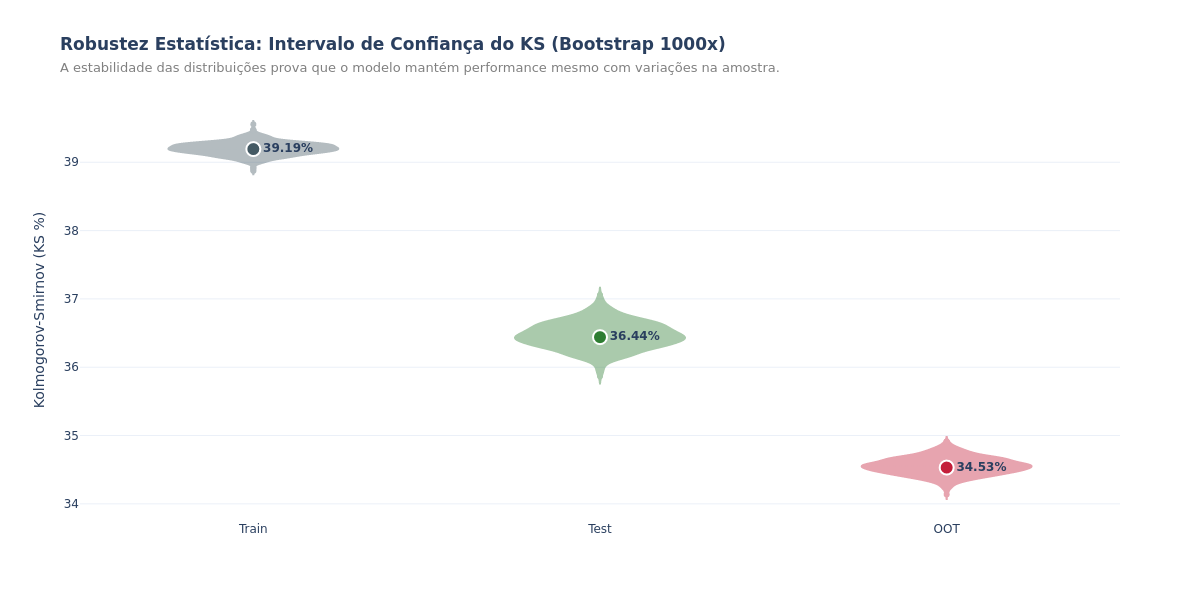

In [19]:
# ---------------------------------------------------------
# 12. BOOTSTRAP CI: ESTABILIDADE ESTATÍSTICA
# ---------------------------------------------------------
print("⚙️ Calculando Intervalos de Confiança (Bootstrap 1000x)...")

def bootstrap_ks(y_true, y_prob, n_bootstrap=1000, random_state=42):
    rng = np.random.RandomState(random_state)
    n = len(y_true)
    ks_values = []
    y_t = y_true.values if hasattr(y_true, 'values') else np.array(y_true)
    y_p = y_prob.values if hasattr(y_prob, 'values') else np.array(y_prob)
    for _ in range(n_bootstrap):
        idx = rng.choice(n, size=n, replace=True)
        y_b, p_b = y_t[idx], y_p[idx]
        if len(np.unique(y_b)) < 2: continue
        fpr, tpr, _ = roc_curve(y_b, p_b)
        ks_values.append(max(tpr - fpr) * 100)
    return np.array(ks_values)

ks_tr_real = calc_ks(y_train, prob_train)
ks_te_real = calc_ks(y_test, prob_test)
ks_oo_real = calc_ks(y_oot, prob_oot_final)

ks_boot_train = bootstrap_ks(y_train, prob_train, 1000)
ks_boot_test  = bootstrap_ks(y_test, prob_test, 1000)
ks_boot_oot   = bootstrap_ks(y_oot, prob_oot_final, 1000) 

fig_boot = go.Figure()
datasets = [('Train', ks_boot_train, ks_tr_real, COLORS['neutral']), ('Test', ks_boot_test, ks_te_real, COLORS['good']), ('OOT', ks_boot_oot, ks_oo_real, COLORS['accent'])]
for name, boot_data, real_ks, color in datasets:
    fig_boot.add_trace(go.Violin(x=[name] * len(boot_data), y=boot_data, name=name, line_color=color, fillcolor=color, opacity=0.4, meanline_visible=True, showlegend=False))
    fig_boot.add_trace(go.Scatter(x=[name], y=[real_ks], mode='markers+text', marker=dict(size=14, color=color, line=dict(width=2, color='white')), text=[f"<b>{real_ks:.2f}%</b>"], textposition="middle right", showlegend=False))
fig_boot.update_layout(title="<b>Robustez Estatística: Intervalo de Confiança do KS (Bootstrap 1000x)</b><br><span style='font-size:13px;color:gray'>A estabilidade das distribuições prova que o modelo mantém performance mesmo com variações na amostra.</span>", yaxis_title="Kolmogorov-Smirnov (KS %)", template="plotly_white", height=600, width=1200, plot_bgcolor='rgba(0,0,0,0)')
fig_boot.write_image(FIGURES_DIR / '12_confianca_ks_bootstrap_v1.png', scale=2)
fig_boot.show(renderer='png')

📊 Gerando Curva de Evolução de Performance (Estabilidade)...


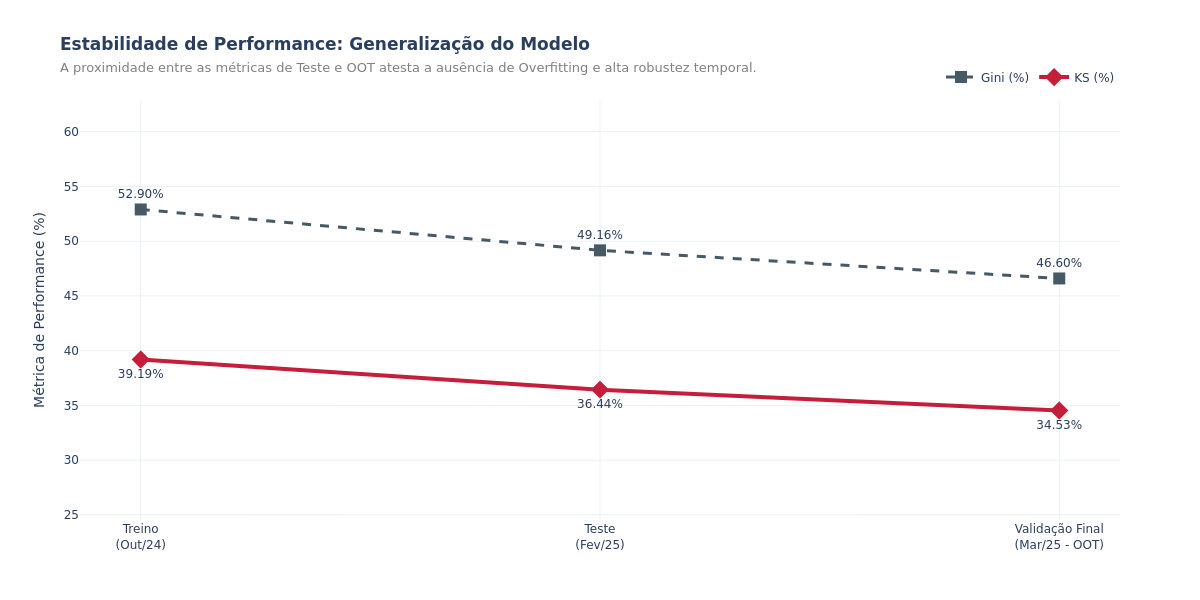

In [20]:
# ---------------------------------------------------------
# 13. ESTABILIDADE DE PERFORMANCE: TRAIN -> TEST -> OOT 
# ---------------------------------------------------------
print("📊 Gerando Curva de Evolução de Performance (Estabilidade)...")

ks_tr_val = calc_ks(y_train, prob_train)
ks_te_val = calc_ks(y_test, prob_test)
ks_oo_val = calc_ks(y_oot, prob_oot_final) 

gini_tr_val = (2 * roc_auc_score(y_train, prob_train) - 1) * 100
gini_te_val = (2 * roc_auc_score(y_test, prob_test) - 1) * 100
gini_oo_val = (2 * roc_auc_score(y_oot, prob_oot_final) - 1) * 100

etapas = ['Treino<br>(Out/24)', 'Teste<br>(Fev/25)', 'Validação Final<br>(Mar/25 - OOT)']
ks_vals = [ks_tr_val, ks_te_val, ks_oo_val]
gini_vals = [gini_tr_val, gini_te_val, gini_oo_val]

fig_evol = go.Figure()
fig_evol.add_trace(go.Scatter(x=etapas, y=gini_vals, mode='lines+markers+text', name='Gini (%)', line=dict(color=COLORS['primary'], width=3, dash='dash'), marker=dict(size=12, symbol='square'), text=[f"{v:.2f}%" for v in gini_vals], textposition="top center"))
fig_evol.add_trace(go.Scatter(x=etapas, y=ks_vals, mode='lines+markers+text', name='KS (%)', line=dict(color=COLORS['accent'], width=4), marker=dict(size=14, symbol='diamond'), text=[f"{v:.2f}%" for v in ks_vals], textposition="bottom center"))
fig_evol.update_layout(title="<b>Estabilidade de Performance: Generalização do Modelo</b><br><span style='font-size:13px;color:gray'>A proximidade entre as métricas de Teste e OOT atesta a ausência de Overfitting e alta robustez temporal.</span>", yaxis_title="Métrica de Performance (%)", height=600, width=1200, template="plotly_white", hovermode="x unified", legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1))
fig_evol.update_yaxes(range=[min(ks_vals)-10, max(gini_vals)+10])
fig_evol.write_image(FIGURES_DIR / '13_evolucao_de_performance_v1.png', scale=2)
fig_evol.show(renderer='png')

📊 Gerando Visualização Estratégica de Swap (Oportunidade vs Proteção)...


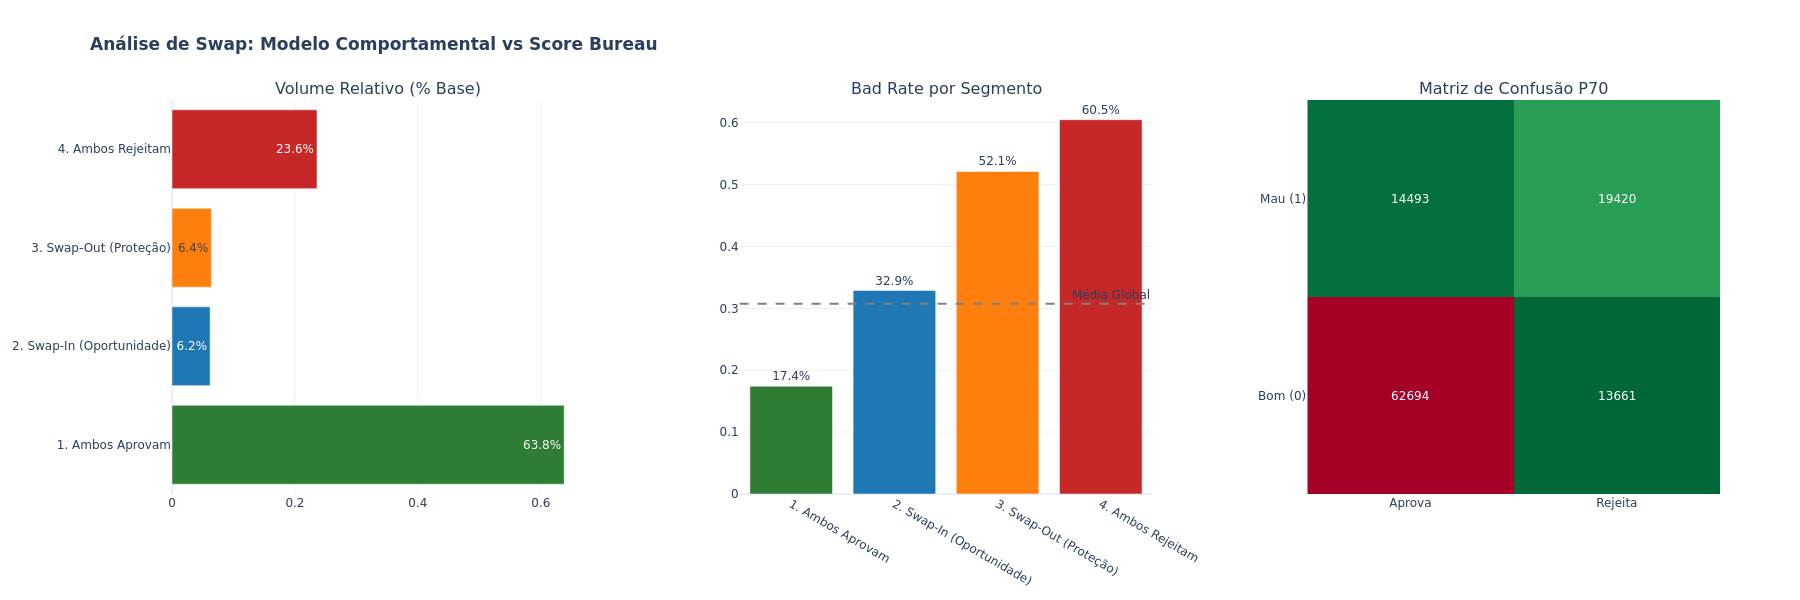

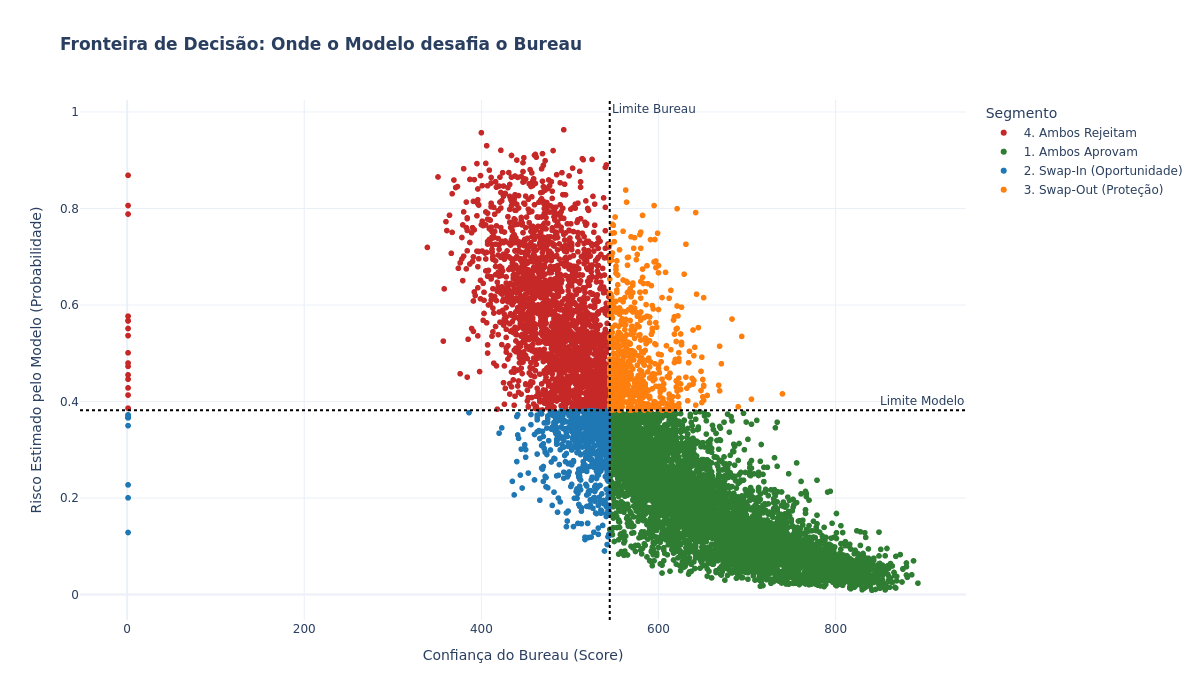

In [21]:
# ---------------------------------------------------------
# 14. SUBPLOTS DE PERFOMANCE POR SEGMENTO
# ---------------------------------------------------------
print("📊 Gerando Visualização Estratégica de Swap (Oportunidade vs Proteção)...")

swap_colors_hex = {'1. Ambos Aprovam': COLORS['good'], '4. Ambos Rejeitam': COLORS['bad'], '2. Swap-In (Oportunidade)': '#1f77b4', '3. Swap-Out (Proteção)': '#ff7f0e'}
fig_swap = make_subplots(rows=1, cols=3, subplot_titles=('Volume Relativo (% Base)', 'Bad Rate por Segmento', 'Matriz de Confusão P70'), horizontal_spacing=0.1)
fig_swap.add_trace(go.Bar(y=swap_summary['categoria'], x=swap_summary['% Base'], orientation='h', marker_color=[swap_colors_hex[c] for c in swap_summary['categoria']], texttemplate='%{x:.1%}', textposition='inside'), row=1, col=1)
fig_swap.add_trace(go.Bar(x=swap_summary['categoria'], y=swap_summary['Bad_Rate'], marker_color=[swap_colors_hex[c] for c in swap_summary['categoria']], texttemplate='%{y:.1%}', textposition='outside'), row=1, col=2)
fig_swap.add_hline(y=y_controle.mean(), line_dash='dash', line_color='gray', annotation_text='Média Global', row=1, col=2)
cm = confusion_matrix(df_swap['target'], y_pred_modelo)
fig_swap.add_trace(go.Heatmap(z=cm, x=['Aprova', 'Rejeita'], y=['Bom (0)', 'Mau (1)'], colorscale='RdYlGn_r', text=cm, texttemplate="%{text}", showscale=False), row=1, col=3)
fig_swap.update_layout(template='plotly_white', height=600, width=1800, title_text='<b>Análise de Swap: Modelo Comportamental vs Score Bureau</b>', showlegend=False)
fig_swap.write_image(FIGURES_DIR / '14_analises_de_swap_v1.png', scale=2)
fig_swap.show(renderer='png')

# ---------------------------------------------------------
# 15.: DISPERSÃO DA FRONTEIRA DE DECISÃO
# ---------------------------------------------------------
df_swap_plot = df_swap.sample(n=min(10000, len(df_swap)), random_state=42)

fig_scatter = px.scatter(
    df_swap_plot, x='bur_score_02', y='prob_modelo', color='categoria', 
    color_discrete_map=swap_colors_hex,
    title='<b>Fronteira de Decisão: Onde o Modelo desafia o Bureau</b>',
    labels={'bur_score_02': 'Score Bureau (Legado)', 'prob_modelo': 'Probabilidade Modelo (Risco)', 'categoria': 'Segmento'}
)

fig_scatter.add_vline(x=cutoff_bureau, line_dash="dot", line_color="black", annotation_text="Limite Bureau")
fig_scatter.add_hline(y=cutoff_modelo, line_dash="dot", line_color="black", annotation_text="Limite Modelo")

fig_scatter.update_layout(
    template='plotly_white', height=700, width=1200,
    xaxis_title="Confiança do Bureau (Score)", 
    yaxis_title="Risco Estimado pelo Modelo (Probabilidade)"
)
fig_scatter.write_image(FIGURES_DIR / '15_dispersao_de_swap_v1.png', scale=2)
fig_scatter.show(renderer='png')